# Urban Runoff — Climate Change & Urbanization Analysis

Refactored notebook. Retains 100 % of the original functionality
while being easy to configure and extend.

### Figures produced
| Figure | Metric |
|--------|--------|
| Fig 1  | Peak runoff discharge |
| Fig 2  | Total runoff |

Each figure has three panels:
* **(a)** top, full width — ECDF on a logit scale with bootstrap shading
* **(b)** bottom-left — city-scale percentile differences (Future − Historical)
* **(c)** bottom-right — neighbourhood-scale percentile differences


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter
from scipy import stats


## 1 · Configuration

Edit **only this cell** to control paths, scenarios, metrics, and style.
All other cells adapt automatically.


In [3]:
# ═══════════════════════════════════════════════════════════════════
# USER CONFIGURATION — edit here, then run all cells
# ═══════════════════════════════════════════════════════════════════

# ── Paths ─────────────────────────────────────────────────────────
SIM_DIR  = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion"
SAVE_DIR = r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"

# ── Event filtering ───────────────────────────────────────────────
RAIN_FILTER_MM  = 10       # [mm] minimum basin rainfall to keep an event
SHIFT_THRESHOLD = 20_000   # [m]  maximum |Y-shift| allowed

# ── Bootstrap ─────────────────────────────────────────────────────
N_BOOT = 2000   # number of bootstrap resamples
ALPHA  = 0.05   # significance level  →  95 % CI

# ── Percentiles shown in the bar panels ───────────────────────────
PERCENTILES = [5, 10, 90, 95]

# ── Scenario for the top CDF panel (a) ───────────────────────────
CDF_SCENARIO = '73% urbanization'

# ── Scenarios for the bar panels (b, c) ──────────────────────────
BAR_SCENARIOS = ['38% urbanization', '73% urbanization', '81% urbanization']
# BAR_SCENARIOS = ALL_SCENARIOS  # uncomment this line to show all scenarios
# ── All available scenarios (uncomment any to add it to BAR_SCENARIOS) ─
ALL_SCENARIOS = [
    '38% urbanization', '42% urbanization', '46% urbanization',
    '49% urbanization', '53% urbanization', '57% urbanization',
    '73% urbanization', '81% urbanization', '83% urbanization',
    '87% urbanization',
]

# ── Column definitions ────────────────────────────────────────────
# Maps (scale, metric) -> (hist_col_tuple, fut_col_tuple, x_axis_label)
# Adjust the column tuples here if the pickle schema ever changes.
COLUMN_DEFS = {
    ('city',         'peak'):  (
        ('historical', 'basin discharge',        'max_discharge'),
        ('future',     'basin discharge',        'max_discharge'),
        r'Peak discharge [m$^3$ s$^{-1}$]',
    ),
    ('city',         'total'): (
        ('historical', 'basin discharge',        'total_discharge'),
        ('future',     'basin discharge',        'total_discharge'),
        r'Total runoff volume [m$^3$]',
    ),
    ('neighborhood', 'peak'):  (
        ('historical', 'Max_Specific_Discharge', 'max_discharge'),
        ('future',     'Max_Specific_Discharge', 'max_discharge'),
        r'Specific peak discharge [m$^3$ s$^{-1}$ km$^{-2}$]',
    ),
    ('neighborhood', 'total'): (
        ('historical', 'Max_Specific_Discharge', 'total_discharge'),
        ('future',     'Max_Specific_Discharge', 'total_discharge'),
        r'Specific total runoff [m$^3$ km$^{-2}$]',
    ),
}

# ── Global figure style ───────────────────────────────────────────
plt.rcParams.update({'font.family': 'Arial', 'font.size': 16, 'axes.linewidth': 1.0})

print("Configuration loaded.")
print(f"  CDF scenario : {CDF_SCENARIO}")
print(f"  Bar scenarios: {BAR_SCENARIOS}")
print(f"  Percentiles  : {PERCENTILES}")


Configuration loaded.
  CDF scenario : 73% urbanization
  Bar scenarios: ['38% urbanization', '73% urbanization', '81% urbanization']
  Percentiles  : [5, 10, 90, 95]


## 2 · Data Loading & Filtering


In [4]:
# Mapping from scenario label to pickle filename
_PKL_MAP = {
    '38% urbanization': 'urbanization_1_0.pkl',
    '42% urbanization': 'urbanization_1_1.pkl',
    '46% urbanization': 'urbanization_1_2.pkl',
    '49% urbanization': 'urbanization_1_3.pkl',
    '53% urbanization': 'urbanization_1_4.pkl',
    '57% urbanization': 'urbanization_1_5.pkl',
    '73% urbanization': 'urbanization_2_0.pkl',
    '81% urbanization': 'urbanization_3_0.pkl',
    '83% urbanization': 'urbanization_4_0.pkl',
    '87% urbanization': 'urbanization_5_0.pkl',
}

# Fixed columns used ONLY for the event-quality filter (independent of metric choice)
_F_RAIN_H = ('historical', 'full_basin',      'total_rain')
_F_RAIN_F = ('future',     'full_basin',      'total_rain')
_F_DIS_H  = ('historical', 'basin discharge', 'max_discharge')
_F_DIS_F  = ('future',     'basin discharge', 'max_discharge')
_F_Y      = ('y', '', '')
_F_EV     = ('event_num', '', '')


def _filter_events(df, rain_mm, shift_m):
    # Remove weak-rain events and extreme-shift rows
    bad = []
    for ev in df[_F_EV].unique():
        sub = df[df[_F_EV] == ev]
        rain_weak = (sub[_F_RAIN_H] < rain_mm).all() and \
                    (sub[_F_RAIN_F] < rain_mm).all()
        shift_big = (np.abs(sub[_F_DIS_F].values - sub[_F_DIS_H].values) > shift_m).any()
        if rain_weak or shift_big:
            bad.append(ev)
    df = df[~df[_F_EV].isin(bad)]
    y_vals = np.arange(-shift_m, shift_m + 1, 500)
    df = df[df[_F_Y].isin(y_vals)]
    print(f"    Removed {len(bad)} events | {df.shape[0]} rows kept")
    return df


def load_data(sim_dir, scenarios, hist_col, fut_col,
              rain_filter_mm=RAIN_FILTER_MM, shift_threshold=SHIFT_THRESHOLD):
    # Load SWMM simulation pickles and return filtered arrays.
    # Returns: dict {label: {'historical': np.ndarray, 'future': np.ndarray,
    #                        'event_num': np.ndarray}}
    data = {}
    for label in scenarios:
        pkl_path = os.path.join(sim_dir, _PKL_MAP[label])
        print(f"  Loading {label} ...")
        df = pd.read_pickle(pkl_path)
        df = _filter_events(df, rain_filter_mm, shift_threshold)
        data[label] = {
            'historical': df[hist_col].values,
            'future':     df[fut_col].values,
            'event_num':  df[_F_EV].values,
        }
    return data


print("Data-loading functions defined.")


Data-loading functions defined.


In [5]:
# Preview the raw dataset before any filtering is applied.
# Change the scenario below if you want to inspect a different file.
preview_scenario = CDF_SCENARIO
preview_path = os.path.join(SIM_DIR, _PKL_MAP[preview_scenario])
raw_df = pd.read_pickle(preview_path)
raw_df.head(10)


event_num  x      y        d      historical                \
                               basin discharge                 
                               total_discharge max_discharge   
0        01  0 -20000  20000.0   170919.489744     13.216708   
1        01  0 -19500  19500.0   174106.310232     11.878566   
2        01  0 -19000  19000.0   174102.015462      9.314260   
3        01  0 -18500  18500.0   171682.550868      7.905008   
4        01  0 -18000  18000.0   164355.670565      7.285154   
5        01  0 -17500  17500.0   154331.308905      6.616781   
6        01  0 -17000  17000.0   139663.260733      5.798620   
7        01  0 -16500  16500.0   124074.441029      5.063628   
8        01  0 -16000  16000.0   106053.468587      4.323676   
9        01  0 -15500  15500.0    89942.988913      3.621486   

                                                                \
                                                    full_basin   
  swmm_max_outflow_time runoff_coefficient max_10min_intensity   
0   1991-11-04 03:20:00           0.357158           22.087233   
1   1991-11-04 03:20:00           0.360466           22.427937   
2   1991-11-04 03:20:00           0.362066           21.873482   
3   1991-11-03 10:10:00           0.361285           20.904474   
4   1991-11-03 10:10:00           0.356254           19.271095   
5   1991-11-03 10:10:00           0.347239           17.440710   
6   1991-11-03 10:10:00           0.330770           15.371350   
7   1991-11-03 10:10:00           0.311176           13.298753   
8   1991-11-03 10:10:00           0.283370           11.329184   
9   1991-11-03 10:10:00           0.256524            9.467923   

                       ...                 future                  \
                       ... Min_Specific_Discharge                   
  max_20min_intensity  ...          max_discharge total_discharge   
0           15.040384  ...                   0.06          159.80   
1           14.413685  ...                   0.07          165.44   
2           13.383315  ...                   0.08          171.08   
3           12.682417  ...                   0.10          180.48   
4           11.998864  ...                   0.11          182.36   
5           11.173980  ...                   0.13          193.64   
6           10.113207  ...                   0.14          195.52   
7            8.991518  ...                   0.14          188.00   
8            7.814605  ...                   0.14          186.12   
9            6.660665  ...                   0.13          159.80   

                                                                        \
                     Most_Urban_S27                                      
  runoff_coefficient  max_discharge total_discharge runoff_coefficient   
0              0.019           7.04         29200.2              0.774   
1              0.019           7.55         29479.0              0.780   
2              0.019           7.75         30061.2              0.787   
3              0.020           7.79         30618.8              0.793   
4              0.020           7.51         31734.0              0.797   
5              0.020           8.45         32726.2              0.800   
6              0.020           9.04         32513.0              0.798   
7              0.020           9.51         32283.4              0.795   
8              0.020           8.89         29356.0              0.779   
9              0.019           8.23         26584.4              0.761   

                                                                            
  Least_Urban_S28                                             spatial_rain  
    max_discharge total_discharge runoff_coefficient wet_area_percent_mean  
0            0.06          159.80              0.019             12.528695  
1            0.07          165.44              0.019             12.322054  
2            0.08          171.08              0.019            

## 3 · Bootstrap & ECDF Utilities


In [6]:
# ── Logit helpers (for CDF panel logit-scale Y axis) ─────────────
def _logit_base(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log10(p / (1 - p))

def _logit_scaled(p, strength=1.0, eps=1e-6):
    return _logit_base(p, eps=eps) * strength


# ── ECDF on a common x-grid ───────────────────────────────────────
def _make_x_grid(a, b, n=512):
    xlo = min(a.min(), b.min())
    xhi = max(a.max(), b.max())
    if xlo == xhi:
        d = abs(xlo) * 1e-9 or 1e-9
        xlo, xhi = xlo - d, xhi + d
    return np.linspace(xlo, xhi, n)

def _ecdf_on_grid(values, x_grid):
    v = np.sort(np.asarray(values))
    return np.searchsorted(v, x_grid, side='right') / float(v.size)


# ── Pooled bootstrap band (for CDF panel) ─────────────────────────
def _pooled_bootstrap_band(values, x_grid, n_boot=1000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    v   = np.asarray(values)
    n   = v.size
    boot = np.stack([
        _ecdf_on_grid(v[rng.integers(0, n, size=n)], x_grid)
        for _ in range(n_boot)
    ])
    lo = np.nanpercentile(boot, 100 * alpha / 2,        axis=0)
    hi = np.nanpercentile(boot, 100 * (1 - alpha / 2),  axis=0)
    return lo, hi


# ── Percentile bootstrap CI (for bar panels) ──────────────────────
def _bootstrap_ci(values, q, n_boot=2000, alpha=0.05, seed=0):
    # Returns (center, lower_halfwidth, upper_halfwidth) for the q-th percentile
    v = np.asarray(values)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan, np.nan, np.nan
    rng   = np.random.default_rng(seed)
    n     = v.size
    boots = np.percentile(v[rng.integers(0, n, size=(n_boot, n))], q, axis=1)
    lo, hi = np.nanpercentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return np.percentile(v, q), np.percentile(v, q) - lo, hi - np.percentile(v, q)


print("Bootstrap utilities defined.")


Bootstrap utilities defined.


# ── Shared colour palette ─────────────────────────────────────────


In [7]:
# ── Shared colour palette ─────────────────────────────────────────
_HIST_COLOR = '#1E3A5F'
_HIST_FILL  = '#89AED2'
_FUT_COLOR  = '#7B1121'
_FUT_FILL   = '#E594A4'
_PCT_TICKS  = np.array([0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])
_BAR_COLORS = {5: '#1c5d99', 10: '#7db9e8', 90: '#fb9a99', 95: '#e31a1c'}


def plot_cdf_panel(ax, hist_values, fut_values, x_label,
                   alpha=0.05, n_boot=1000, strength=1.0,
                   panel_label='a',
                   hist_label='Historical', fut_label='Future',
                   show_stats_box=True):
    # Draw an ECDF (logit Y-scale) with pooled bootstrap shading into ax.
    x  = _make_x_grid(np.asarray(hist_values), np.asarray(fut_values))
    Fh = _ecdf_on_grid(hist_values, x)
    Ff = _ecdf_on_grid(fut_values,  x)

    lo_h, hi_h = _pooled_bootstrap_band(hist_values, x, n_boot=n_boot, alpha=alpha, seed=0)
    lo_f, hi_f = _pooled_bootstrap_band(fut_values,  x, n_boot=n_boot, alpha=alpha, seed=1)

    L = lambda p: _logit_scaled(p, strength=strength)

    ax.fill_between(x, L(lo_h), L(hi_h), color=_HIST_FILL, alpha=0.35, linewidth=0)
    ax.fill_between(x, L(lo_f), L(hi_f), color=_FUT_FILL,  alpha=0.35, linewidth=0)
    ax.plot(x, L(Fh), lw=1.8, color=_HIST_COLOR, label=hist_label)
    ax.plot(x, L(Ff), lw=1.8, color=_FUT_COLOR,  label=fut_label)

    # Logit Y-axis with percentage labels
    ax.set_yticks(L(_PCT_TICKS))
    ax.set_yticklabels([f'{int(p*100)}%' for p in _PCT_TICKS], fontsize=16)
    ax.set_ylim(-3, 3)
    ax.set_ylabel('CDF', fontsize=17)
    ax.set_xlabel(x_label, fontsize=17)
    ax.set_xlim(left=x.min())

    ax.grid(True, axis='both', ls='--', lw=0.5, alpha=0.5, zorder=0)

    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_color('black')
        sp.set_linewidth(1.0)

    ax.tick_params(axis='both', which='major',
                   direction='in', length=5, width=0.9, colors='black', labelsize=16)
    ax.tick_params(axis='both', which='minor',
                   direction='in', length=3, width=0.6, colors='black')
    ax.minorticks_on()

    ci_pct = int((1 - alpha) * 100)
    handles = [
        mlines.Line2D([], [], color=_HIST_COLOR, lw=1.8, label=hist_label),
        mlines.Line2D([], [], color=_FUT_COLOR,  lw=1.8, label=fut_label),
        Patch(facecolor='#808080', alpha=0.35, edgecolor='none',
              label=f'{ci_pct}% bootstrap CI'),
    ]
    ax.legend(handles=handles, frameon=False, fontsize=16, handlelength=2.0)

    if panel_label:
        ax.text(-0.07, 1.04, panel_label, transform=ax.transAxes,
                fontsize=19, fontweight='bold', ha='left', va='bottom')

    if show_stats_box:
        # ── Distributional shape statistics ───────────────────────────
        h = np.asarray(hist_values)
        f = np.asarray(fut_values)
        h_var,  f_var  = np.var(h),          np.var(f)
        h_skew, f_skew = stats.skew(h),      stats.skew(f)
        h_kurt, f_kurt = stats.kurtosis(h),  stats.kurtosis(f)

        def _fmt(v):
            if v == 0:
                return '  0.000'
            if abs(v) >= 10_000 or abs(v) < 0.001:
                return f'{v:+.2e}'
            return f'{v:+.3f}'

        txt = (
            f"  {'Hist':>10}  {'Fut':>10}  {'Δ (F−H)':>10}\n"
            f"Var  {h_var:>10.3g}  {f_var:>10.3g}  {_fmt(f_var - h_var):>10}\n"
            f"Skew {_fmt(h_skew):>10}  {_fmt(f_skew):>10}  {_fmt(f_skew - h_skew):>10}\n"
            f"Kurt {_fmt(h_kurt):>10}  {_fmt(f_kurt):>10}  {_fmt(f_kurt - h_kurt):>10}"
        )
        ax.text(
            0.98, 0.04, txt,
            transform=ax.transAxes,
            fontsize=11, fontfamily='monospace',
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      alpha=0.88, edgecolor='#aaaaaa', linewidth=0.8),
        )


print("plot_cdf_panel defined.")


plot_cdf_panel defined.


In [8]:
def plot_bar_panel(ax, data_dict, urbanization_levels, percentiles,
                   y_label='', title=None, panel_label=None,
                   n_boot=2000, alpha=0.05, show_legend=False):
    # Draw percentile-difference bars (Future - Historical) with bootstrap CIs into ax.
    x       = np.arange(len(urbanization_levels))
    nP      = len(percentiles)
    barw    = 0.17
    offsets = np.linspace(-0.27, 0.27, nP)

    for i, p in enumerate(percentiles):
        vals, lo_err, hi_err = [], [], []
        for lvl in urbanization_levels:
            h = data_dict[lvl]['historical']
            f = data_dict[lvl]['future']
            ch, loh, hih = _bootstrap_ci(h, p, n_boot, alpha, seed=42)
            cf, lof, hif = _bootstrap_ci(f, p, n_boot, alpha, seed=43)
            vals.append(cf - ch)
            lo_err.append(np.hypot(loh, lof))
            hi_err.append(np.hypot(hih, hif))

        ax.bar(x + offsets[i], vals, width=barw,
               color=_BAR_COLORS[p], edgecolor='none', zorder=3,
               label=f'{p}th pct')
        ax.errorbar(x + offsets[i], vals,
                    yerr=[lo_err, hi_err], fmt='none',
                    ecolor='black', elinewidth=0.7,
                    capsize=2.5, capthick=0.7, zorder=4)

    ax.axhline(0, color='black', lw=0.8, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{float(l.split('%')[0]):.0f}%" for l in urbanization_levels],
        fontsize=16,
    )
    ax.set_xlabel('Urbanization level', fontsize=16)
    ax.set_ylabel(y_label, fontsize=15)

    if title:
        ax.set_title(title, fontsize=17)

    ax.grid(axis='y', ls='--', lw=0.5, alpha=0.4, zorder=0)
    ax.tick_params(axis='both', labelsize=15, width=0.9, length=4, direction='out')

    # Scientific notation on Y-axis
    formatter = ScalarFormatter(useMathText=False)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(formatter)

    # Black spines
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_color('black')
        sp.set_linewidth(1.0)

    if show_legend:
        handles = [Patch(color=_BAR_COLORS[p], label=f'{p}th pct') for p in percentiles]
        ax.legend(handles=handles, frameon=False, fontsize=15)

    if panel_label:
        ax.text(-0.14, 1.04, panel_label, transform=ax.transAxes,
                fontsize=19, fontweight='bold', ha='left', va='bottom')


print("plot_bar_panel defined.")


plot_bar_panel defined.


In [9]:
def make_figure(data_city, data_neighborhood,
               cdf_scenario, bar_scenarios, percentiles,
               x_label_cdf, y_label_city, y_label_nbhd, metric_title,
               alpha=0.05, n_boot=2000,
               figsize=(16, 11), dpi=150,
               show_stats_box=True,
               save_path=None):
    # Build the 3-panel composite figure.
    # Layout:
    #   +────────────────────────────+
    #   |           (a)              |   <- CDF, logit scale, full width
    #   +─────────────┬──────────────+
    #   |     (b)     |     (c)      |   <- percentile diff bars
    #   +─────────────┴──────────────+
    fig = plt.figure(figsize=figsize, dpi=dpi)
    axd = fig.subplot_mosaic(
        [['a', 'a'], ['b', 'c']],
        gridspec_kw={'hspace': 0.28, 'wspace': 0.40, 'height_ratios': [1.2, 1.0]},
    )

    # Panel (a) — CDF
    plot_cdf_panel(
        axd['a'],
        hist_values   = data_city[cdf_scenario]['historical'],
        fut_values    = data_city[cdf_scenario]['future'],
        x_label       = x_label_cdf,
        alpha         = alpha,
        n_boot        = n_boot,
        panel_label   = 'a',
        show_stats_box= show_stats_box,
    )

    # Panel (b) — city scale
    plot_bar_panel(
        axd['b'],
        data_dict           = data_city,
        urbanization_levels = bar_scenarios,
        percentiles         = percentiles,
        y_label             = y_label_city,
        title               = 'City scale',
        panel_label         = 'b',
        n_boot=n_boot, alpha=alpha,
        show_legend         = False,
    )

    # Panel (c) — neighbourhood scale
    plot_bar_panel(
        axd['c'],
        data_dict           = data_neighborhood,
        urbanization_levels = bar_scenarios,
        percentiles         = percentiles,
        y_label             = y_label_nbhd,
        title               = 'Neighbourhood scale',
        panel_label         = 'c',
        n_boot=n_boot, alpha=alpha,
        show_legend         = True,
    )

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, format='pdf', bbox_inches='tight', dpi=max(dpi, 300))
        print(f'Saved -> {save_path}')

    return fig


print("make_figure defined.")


make_figure defined.


## 5 · Figure 1 — Peak discharge

* **(a)** ECDF logit scale for 73 % urbanisation — city-scale peak discharge
* **(b)** City scale percentile differences at 38 %, 73 %, 87 %
* **(c)** Neighbourhood scale percentile differences at 38 %, 73 %, 87 %


=== Figure 1 : Peak Runoff ===
Loading city scale (peak) ...
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
  Loading 38% urbanization ...
    Removed 8 events | 2673 rows kept
  Loading 81% urbanization ...
    Removed 8 events | 2673 rows kept
Loading neighbourhood scale (peak) ...
  Loading 38% urbanization ...
    Removed 8 events | 2673 rows kept
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
  Loading 81% urbanization ...
    Removed 8 events | 2673 rows kept
Saved -> D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig1_peak_runoff.pdf


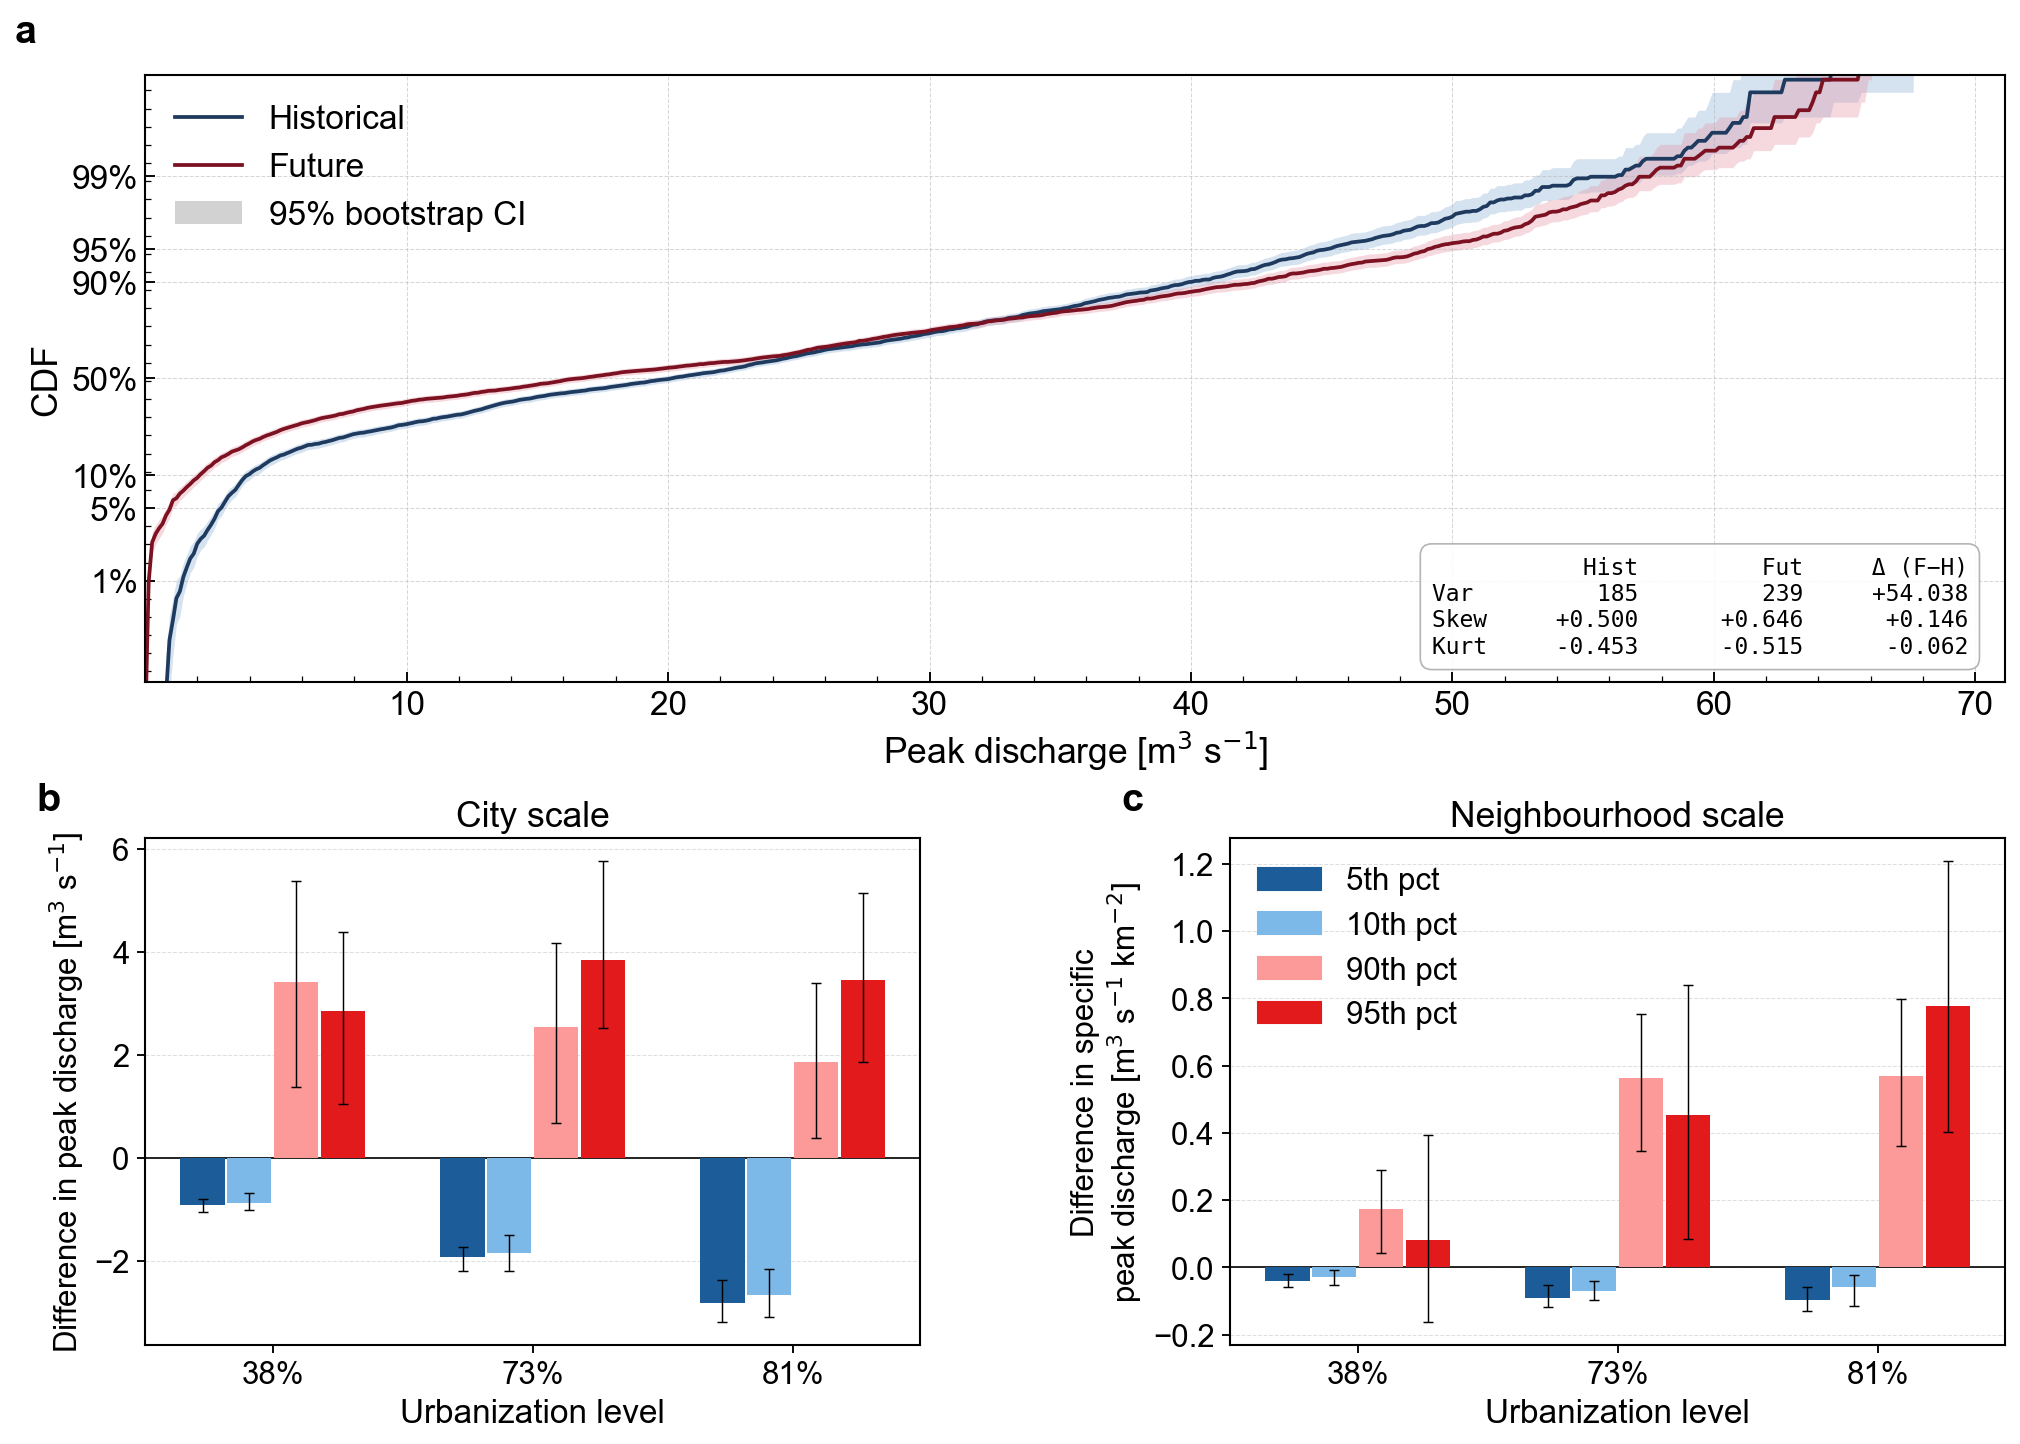

In [10]:
print("=== Figure 1 : Peak Runoff ===")
all_scenarios = list(dict.fromkeys([CDF_SCENARIO] + BAR_SCENARIOS))

hist_col_c, fut_col_c, x_label_peak = COLUMN_DEFS[('city', 'peak')]
print("Loading city scale (peak) ...")
data_city_peak = load_data(SIM_DIR, all_scenarios, hist_col_c, fut_col_c)

hist_col_n, fut_col_n, _ = COLUMN_DEFS[('neighborhood', 'peak')]
print("Loading neighbourhood scale (peak) ...")
data_nbhd_peak = load_data(SIM_DIR, BAR_SCENARIOS, hist_col_n, fut_col_n)

fig1 = make_figure(
    data_city         = data_city_peak,
    data_neighborhood = data_nbhd_peak,
    cdf_scenario      = CDF_SCENARIO,
    bar_scenarios     = BAR_SCENARIOS,
    percentiles       = PERCENTILES,
    x_label_cdf      = x_label_peak,
    y_label_city     = r'Difference in peak discharge [m$^3$ s$^{-1}$]',
    y_label_nbhd     = ('Difference in specific\n'
                        'peak discharge [m$^3$ s$^{-1}$ km$^{-2}$]'),
    metric_title     = 'Peak Runoff',
    alpha             = ALPHA,
    n_boot            = N_BOOT,
    save_path         = os.path.join(SAVE_DIR, 'Fig1_peak_runoff.pdf'),
    show_stats_box= True
)
plt.show()


## 6 · Figure 2 — Total Runoff

Same 3-panel layout as Figure 1, but for total (volumetric) runoff.


=== Figure 2 : Total Runoff ===
Loading city scale (total) ...
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
  Loading 38% urbanization ...
    Removed 8 events | 2673 rows kept
  Loading 81% urbanization ...
    Removed 8 events | 2673 rows kept
Loading neighbourhood scale (total) ...
  Loading 38% urbanization ...
    Removed 8 events | 2673 rows kept
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
  Loading 81% urbanization ...
    Removed 8 events | 2673 rows kept
Saved -> D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig2_total_runoff.pdf


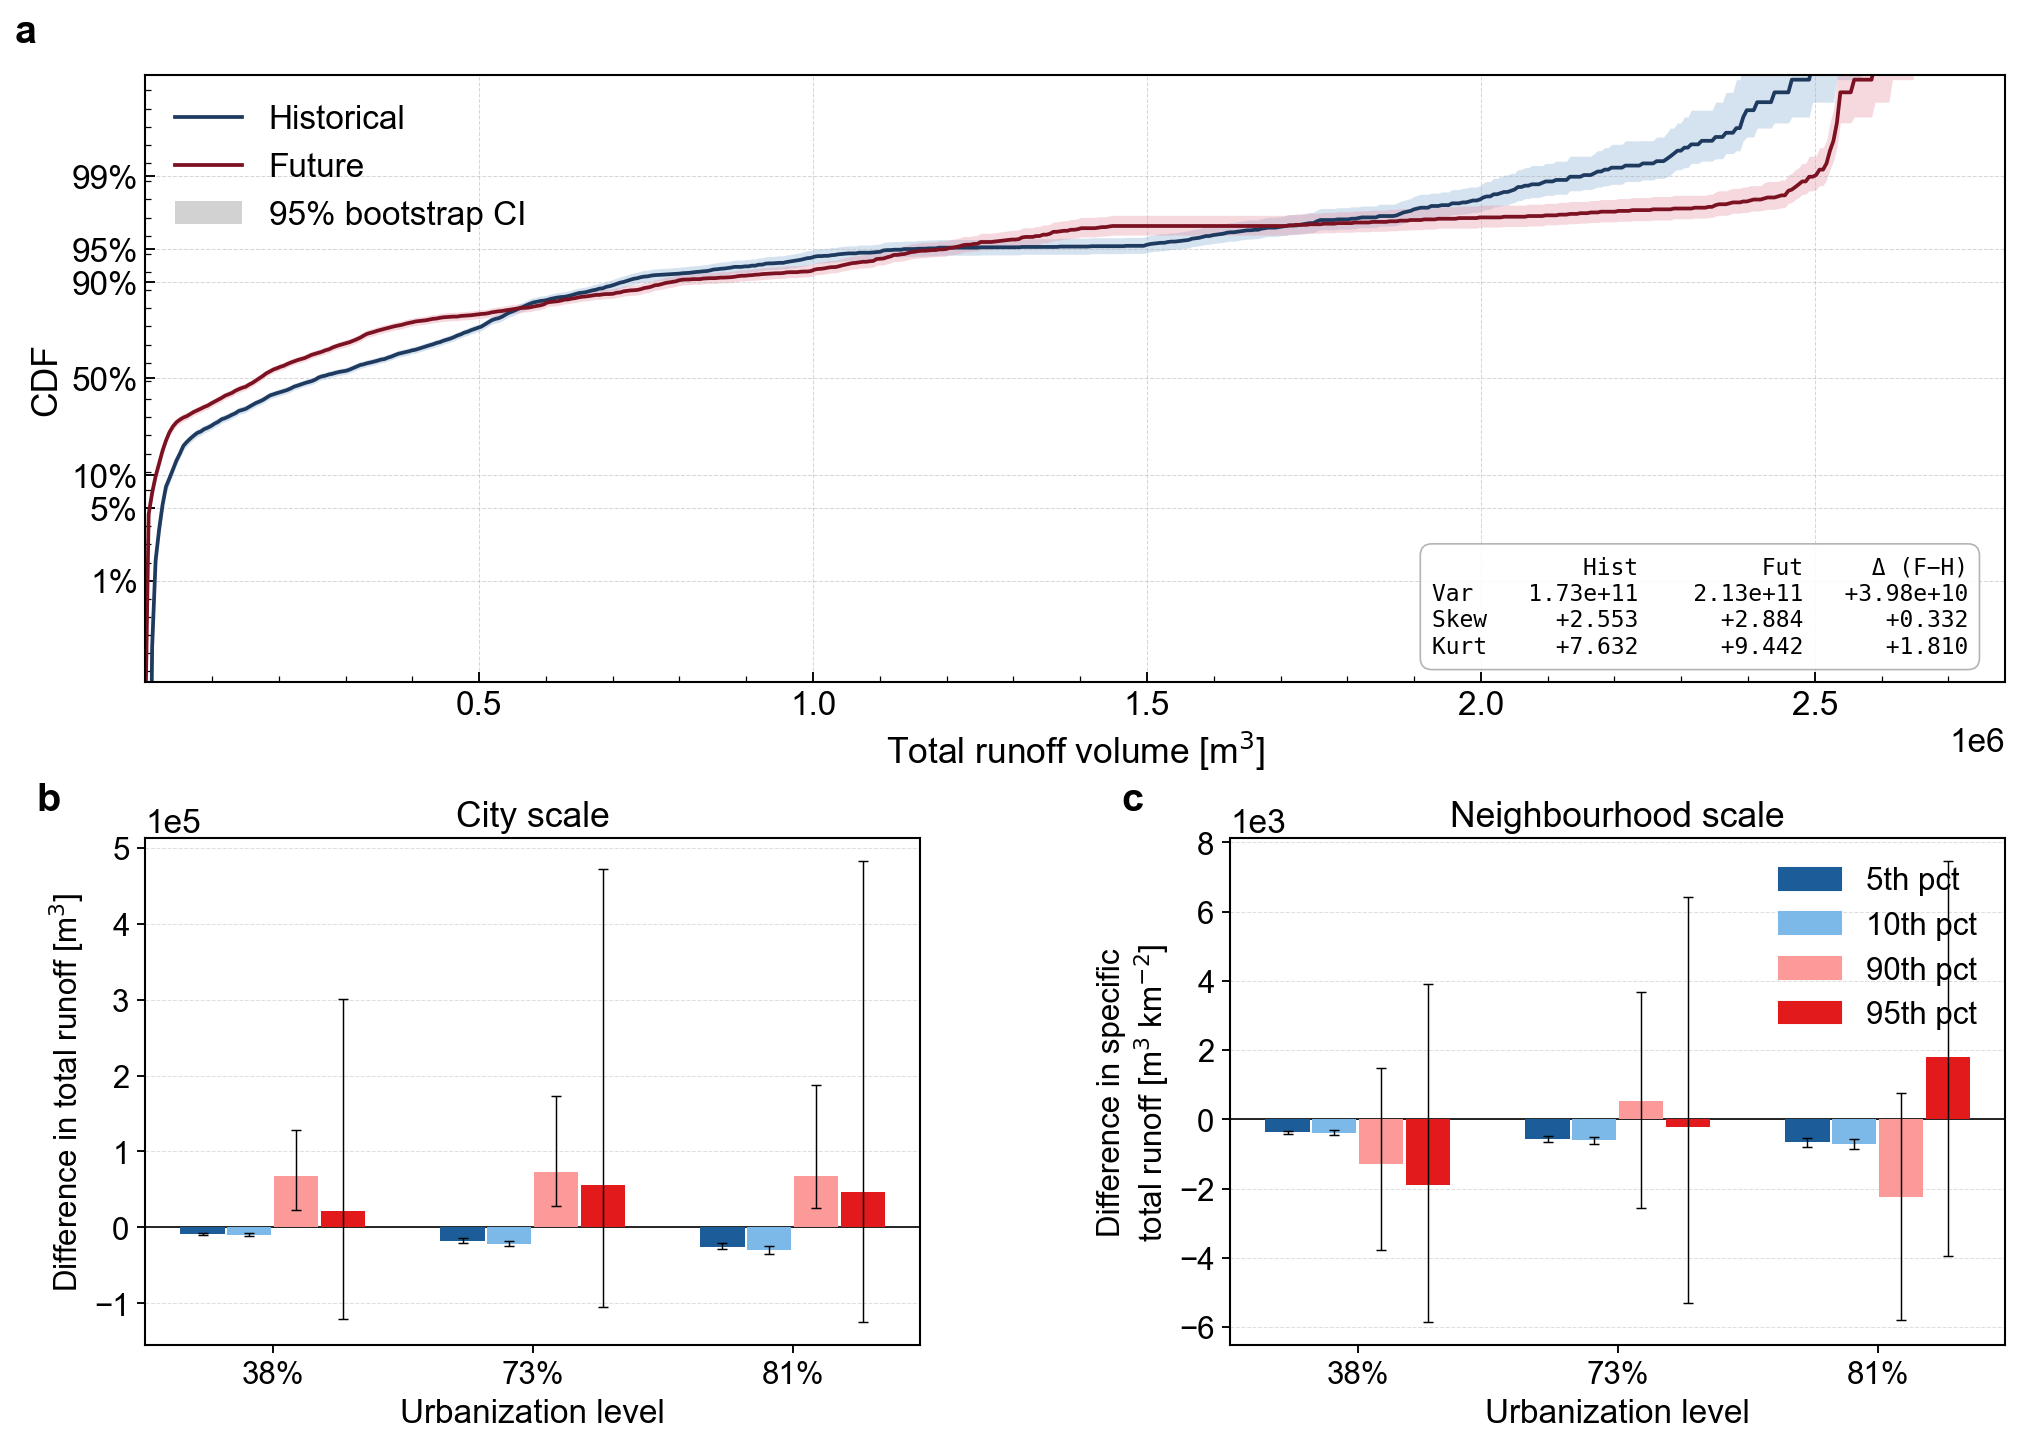

In [26]:
print("=== Figure 2 : Total Runoff ===")
all_scenarios = list(dict.fromkeys([CDF_SCENARIO] + BAR_SCENARIOS))

hist_col_c, fut_col_c, x_label_total = COLUMN_DEFS[('city', 'total')]
print("Loading city scale (total) ...")
data_city_total = load_data(SIM_DIR, all_scenarios, hist_col_c, fut_col_c)

hist_col_n, fut_col_n, _ = COLUMN_DEFS[('neighborhood', 'total')]
print("Loading neighbourhood scale (total) ...")
data_nbhd_total = load_data(SIM_DIR, BAR_SCENARIOS, hist_col_n, fut_col_n)

fig2 = make_figure(
    data_city         = data_city_total,
    data_neighborhood = data_nbhd_total,
    cdf_scenario      = CDF_SCENARIO,
    bar_scenarios     = BAR_SCENARIOS,
    percentiles       = PERCENTILES,
    x_label_cdf      = x_label_total,
    y_label_city     = r'Difference in total runoff [m$^3$]',
    y_label_nbhd     = ('Difference in specific\n'
                        'total runoff [m$^3$ km$^{-2}$]'),
    metric_title     = 'Total Runoff',
    alpha             = ALPHA,
    n_boot            = N_BOOT,
    save_path         = os.path.join(SAVE_DIR, 'Fig2_total_runoff.pdf'),
    show_stats_box=True
)
plt.show()


## 7 · Unshifted event subset

This section repeats the same two figures with the same filtered events, but only keeps the unshifted storm rows where `x = 0` and `y = 0`.



In [12]:
print("=== Unshifted event subset (x=0, y=0) ===")


def load_data_xy0(sim_dir, scenarios, hist_col, fut_col,
                  rain_filter_mm=RAIN_FILTER_MM, shift_threshold=SHIFT_THRESHOLD,
                  x_value=0, y_value=0):
    # Load SWMM simulation pickles, apply the standard event filter,
    # then keep only the unshifted storm row at x=0, y=0.
    data = {}
    for label in scenarios:
        pkl_path = os.path.join(sim_dir, _PKL_MAP[label])
        print(f"  Loading {label} ...")
        df = pd.read_pickle(pkl_path)
        df = _filter_events(df, rain_filter_mm, shift_threshold)
        df = df[(df[('x', '', '')] == x_value) & (df[_F_Y] == y_value)]
        print(f"    Unshifted subset: {df.shape[0]} rows | {df['event_num'].nunique()} events")
        data[label] = {
            'historical': df[hist_col].values,
            'future':     df[fut_col].values,
            'event_num':  df[_F_EV].values,
        }
    return data




=== Unshifted event subset (x=0, y=0) ===


=== Figure 1 : Peak Runoff (Unshifted x=0, y=0) ===
Loading city scale (peak), unshifted ...
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
  Loading 38% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
  Loading 81% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
Loading neighbourhood scale (peak), unshifted ...
  Loading 38% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
  Loading 81% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
Saved -> D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig1_peak_runoff_x0_y0.pdf


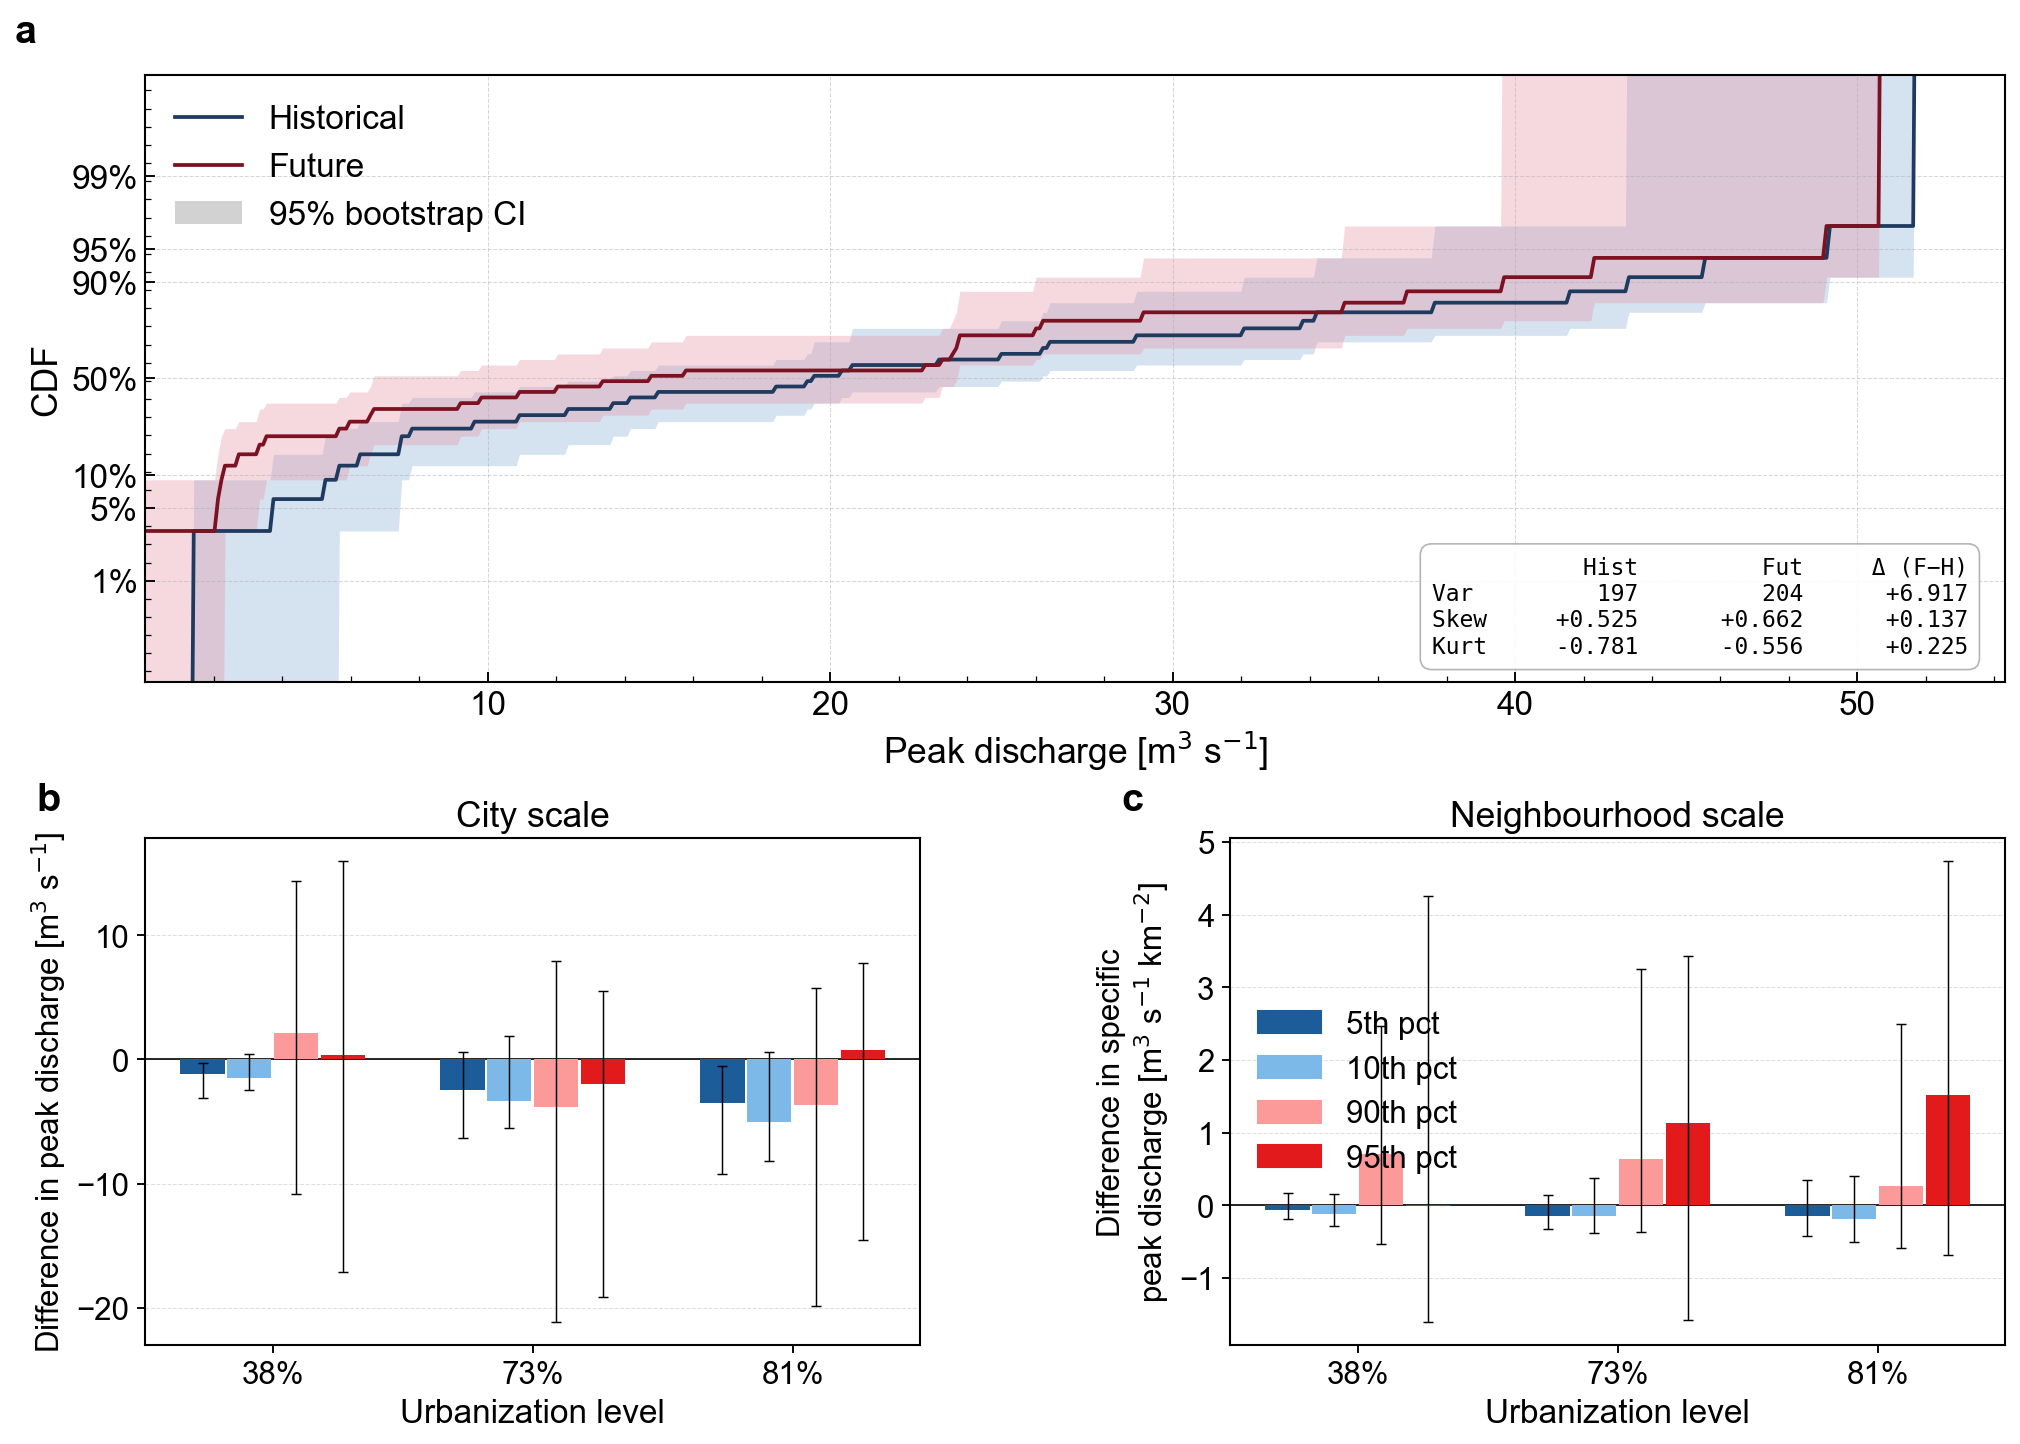

In [13]:
print("=== Figure 1 : Peak Runoff (Unshifted x=0, y=0) ===")
all_scenarios = list(dict.fromkeys([CDF_SCENARIO] + BAR_SCENARIOS))

hist_col_c, fut_col_c, x_label_peak = COLUMN_DEFS[('city', 'peak')]
print("Loading city scale (peak), unshifted ...")
data_city_peak_xy0 = load_data_xy0(SIM_DIR, all_scenarios, hist_col_c, fut_col_c)

hist_col_n, fut_col_n, _ = COLUMN_DEFS[('neighborhood', 'peak')]
print("Loading neighbourhood scale (peak), unshifted ...")
data_nbhd_peak_xy0 = load_data_xy0(SIM_DIR, BAR_SCENARIOS, hist_col_n, fut_col_n)

fig3 = make_figure(
    data_city         = data_city_peak_xy0,
    data_neighborhood = data_nbhd_peak_xy0,
    cdf_scenario      = CDF_SCENARIO,
    bar_scenarios     = BAR_SCENARIOS,
    percentiles       = PERCENTILES,
    x_label_cdf      = x_label_peak,
    y_label_city     = r'Difference in peak discharge [m$^3$ s$^{-1}$]',
    y_label_nbhd     = ('Difference in specific\n'
                        'peak discharge [m$^3$ s$^{-1}$ km$^{-2}$]'),
    metric_title     = 'Peak Runoff (x=0, y=0)',
    alpha             = ALPHA,
    n_boot            = N_BOOT,
    save_path         = os.path.join(SAVE_DIR, 'Fig1_peak_runoff_x0_y0.pdf'),
)
plt.show()



=== Figure 2 : Total Runoff (Unshifted x=0, y=0) ===
Loading city scale (total), unshifted ...
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
  Loading 38% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
  Loading 81% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
Loading neighbourhood scale (total), unshifted ...
  Loading 38% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
  Loading 81% urbanization ...
    Removed 8 events | 2673 rows kept
    Unshifted subset: 33 rows | 33 events
Saved -> D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig2_total_runoff_x0_y0.pdf


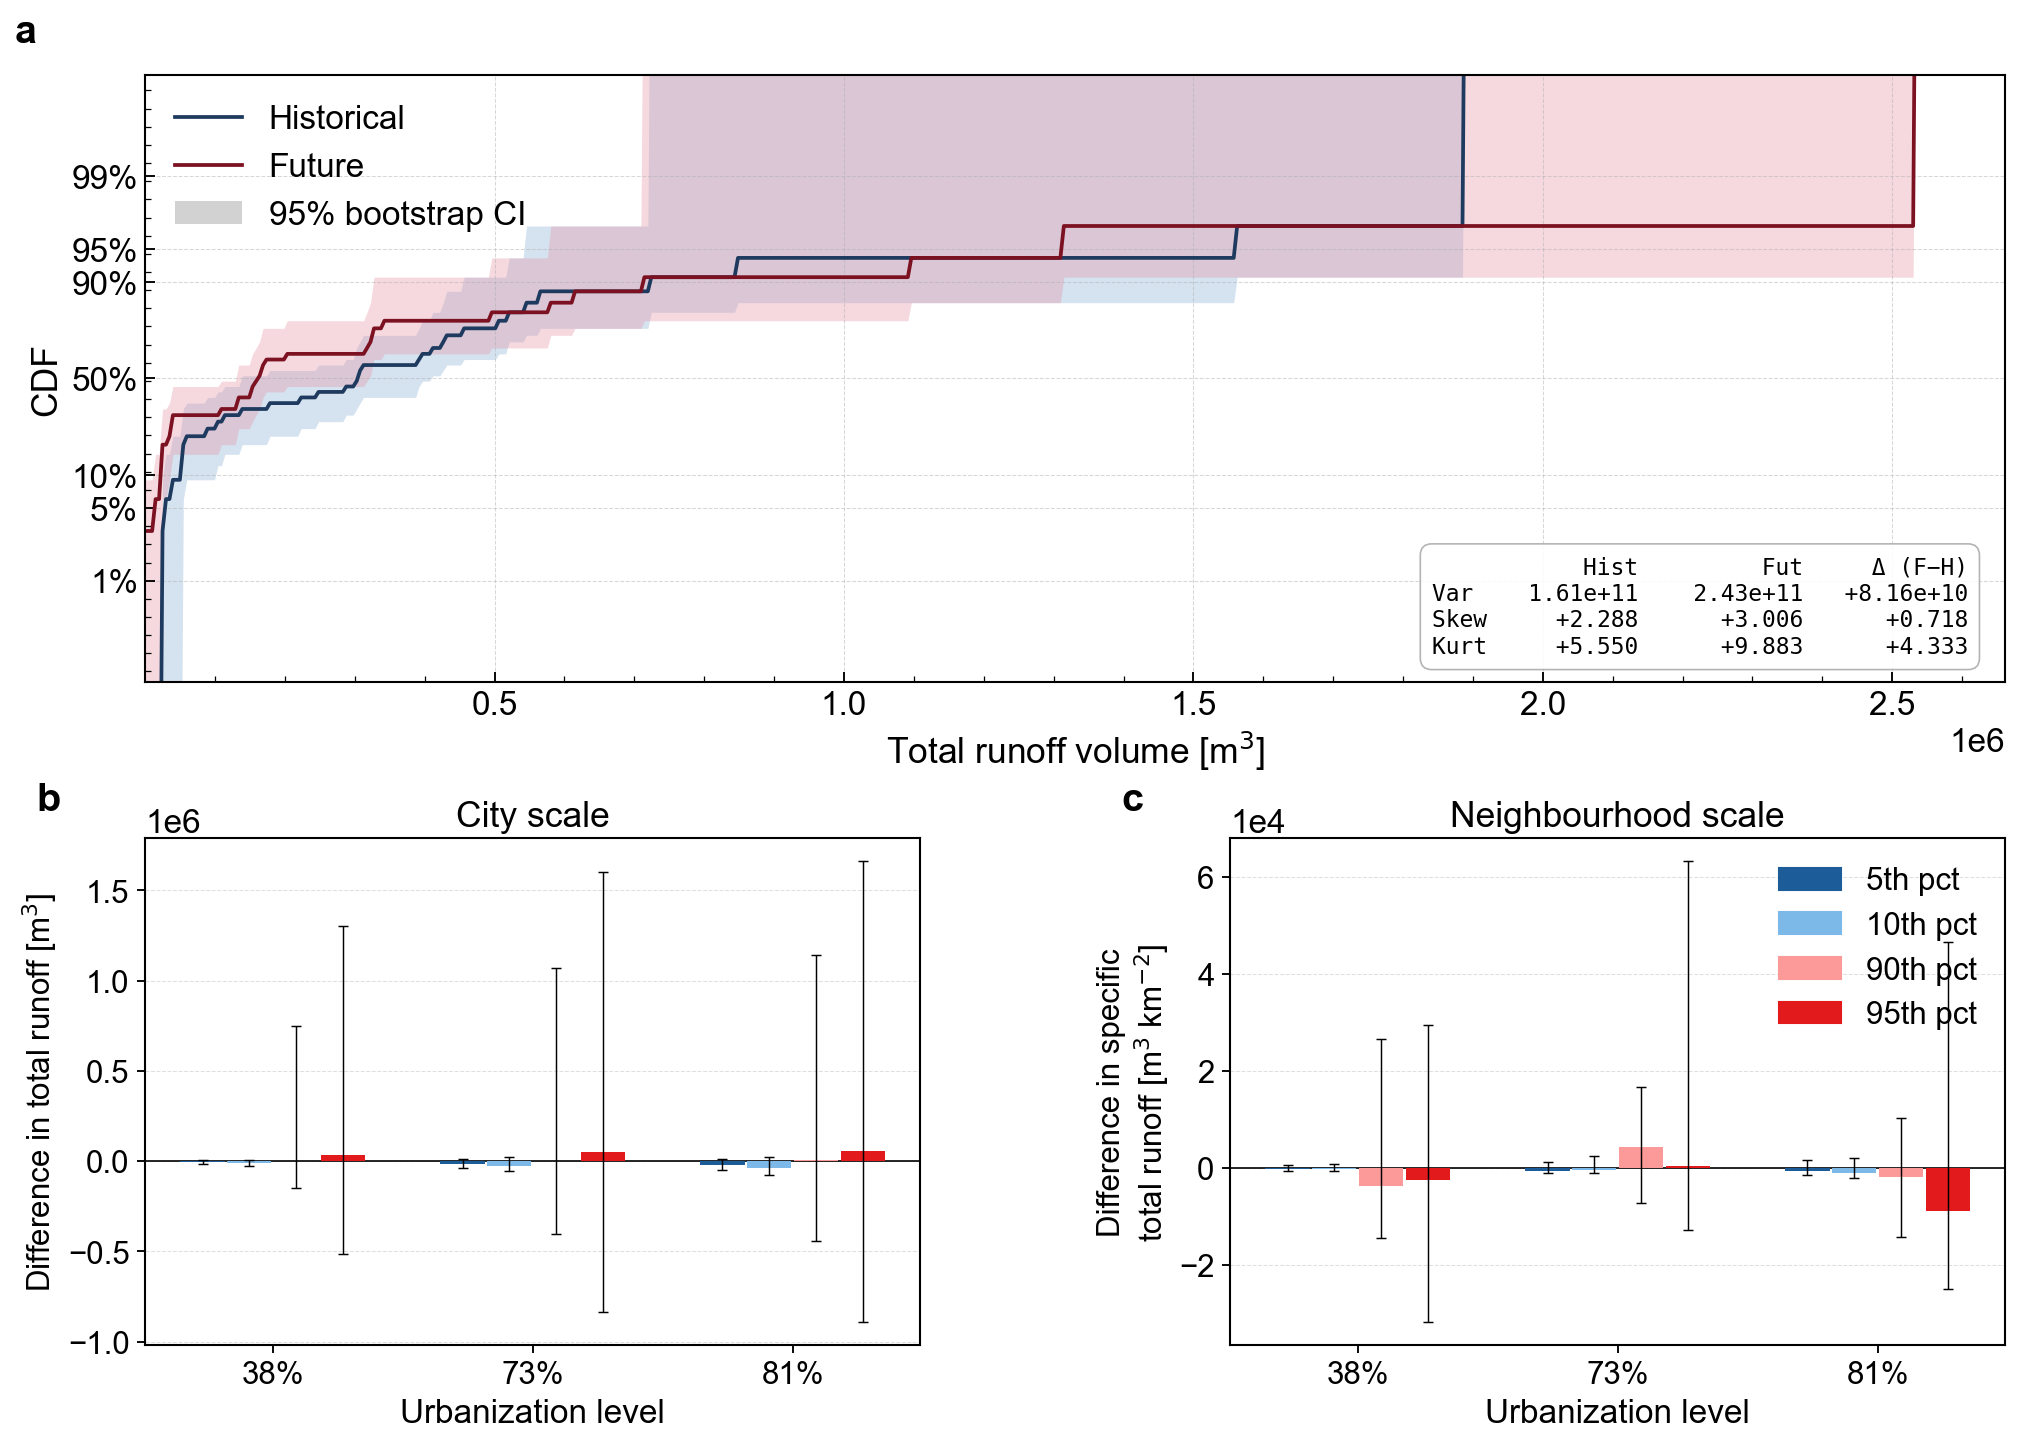

In [14]:
print("=== Figure 2 : Total Runoff (Unshifted x=0, y=0) ===")
all_scenarios = list(dict.fromkeys([CDF_SCENARIO] + BAR_SCENARIOS))

hist_col_c, fut_col_c, x_label_total = COLUMN_DEFS[('city', 'total')]
print("Loading city scale (total), unshifted ...")
data_city_total_xy0 = load_data_xy0(SIM_DIR, all_scenarios, hist_col_c, fut_col_c)

hist_col_n, fut_col_n, _ = COLUMN_DEFS[('neighborhood', 'total')]
print("Loading neighbourhood scale (total), unshifted ...")
data_nbhd_total_xy0 = load_data_xy0(SIM_DIR, BAR_SCENARIOS, hist_col_n, fut_col_n)

fig4 = make_figure(
    data_city         = data_city_total_xy0,
    data_neighborhood = data_nbhd_total_xy0,
    cdf_scenario      = CDF_SCENARIO,
    bar_scenarios     = BAR_SCENARIOS,
    percentiles       = PERCENTILES,
    x_label_cdf      = x_label_total,
    y_label_city     = r'Difference in total runoff [m$^3$]',
    y_label_nbhd     = ('Difference in specific\n'
                        'total runoff [m$^3$ km$^{-2}$]'),
    metric_title     = 'Total Runoff (x=0, y=0)',
    alpha             = ALPHA,
    n_boot            = N_BOOT,
    save_path         = os.path.join(SAVE_DIR, 'Fig2_total_runoff_x0_y0.pdf'),
)
plt.show()



## 8 · Rain-Threshold Sensitivity of the CDF

How sensitive is the historical vs. future ECDF comparison to the minimum-rainfall
filter (`RAIN_FILTER_MM`, §2) applied when loading events? This section repeats
the **(a)**-style CDF panel — historical vs. future, same look as Figures 1–4 —
once per threshold:

```
RAIN_THRESHOLDS_MM = [0, 5, 10, 15, 20]   # [mm]
```

Each subplot is one threshold; inside it, **Historical** and **Future** are
overlaid exactly like the other CDF panels (logit-scale ECDF + bootstrap CI
shading).

By default this uses `CDF_SCENARIO` and the city-scale peak-discharge metric
(same as Figure 1's panel a) — change `THRESH_SCALE` / `THRESH_METRIC` /
`THRESH_SCENARIO` below to compare a different metric or scenario.


In [15]:
# ── Rain thresholds to compare ────────────────────────────────────
RAIN_THRESHOLDS_MM = [0, 5, 10, 15, 20]

# ── Metric / scale / scenario used for this comparison ───────────
# (reuses COLUMN_DEFS from §1 — change to compare a different metric)
THRESH_SCALE    = 'city'
THRESH_METRIC   = 'peak'
THRESH_SCENARIO = CDF_SCENARIO

print(f"Rain thresholds : {RAIN_THRESHOLDS_MM} mm")
print(f"Scenario        : {THRESH_SCENARIO}")
print(f"Scale / metric  : {THRESH_SCALE} / {THRESH_METRIC}")


Rain thresholds : [0, 5, 10, 15, 20] mm
Scenario        : 73% urbanization
Scale / metric  : city / peak


In [16]:
hist_col_t, fut_col_t, x_label_t = COLUMN_DEFS[(THRESH_SCALE, THRESH_METRIC)]

print("Loading data across rain thresholds ...")
data_by_threshold = {}
n_sims_by_threshold = {}
for thr in RAIN_THRESHOLDS_MM:
    print(f"  Rain threshold = {thr} mm")
    loaded = load_data(
        SIM_DIR, [THRESH_SCENARIO], hist_col_t, fut_col_t,
        rain_filter_mm=thr,
    )[THRESH_SCENARIO]
    data_by_threshold[thr] = loaded

    n_events = len(np.unique(loaded['event_num']))
    n_rows   = len(loaded['historical'])
    n_sims   = 2 * n_rows  # historical + future simulations, across all (x, y) shifts
    n_sims_by_threshold[thr] = n_sims
    print(f"    -> {n_events} events | {n_rows} shift-rows | n = {n_sims:,} total simulations (historical + future)")


Loading data across rain thresholds ...
  Rain threshold = 0 mm
  Loading 73% urbanization ...
    Removed 0 events | 3321 rows kept
    -> 41 events | 3321 shift-rows | n = 6,642 total simulations (historical + future)
  Rain threshold = 5 mm
  Loading 73% urbanization ...
    Removed 5 events | 2916 rows kept
    -> 36 events | 2916 shift-rows | n = 5,832 total simulations (historical + future)
  Rain threshold = 10 mm
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
    -> 33 events | 2673 shift-rows | n = 5,346 total simulations (historical + future)
  Rain threshold = 15 mm
  Loading 73% urbanization ...
    Removed 9 events | 2592 rows kept
    -> 32 events | 2592 shift-rows | n = 5,184 total simulations (historical + future)
  Rain threshold = 20 mm
  Loading 73% urbanization ...
    Removed 10 events | 2511 rows kept
    -> 31 events | 2511 shift-rows | n = 5,022 total simulations (historical + future)


In [17]:
def make_threshold_figure(data_by_threshold, n_sims_by_threshold, thresholds, x_label,
                          title, save_path,
                          alpha=ALPHA, n_boot=N_BOOT, ncols=3):
    # Build a grid of CDF panels (Historical vs Future), one per rain threshold.
    n_thr  = len(thresholds)
    nrows  = -(-n_thr // ncols)  # ceil division
    panel_labels = 'abcdefghij'

    fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 5.8 * nrows), dpi=150)
    axes = np.atleast_1d(axes).ravel()

    for i, thr in enumerate(thresholds):
        plot_cdf_panel(
            axes[i],
            hist_values = data_by_threshold[thr]['historical'],
            fut_values  = data_by_threshold[thr]['future'],
            x_label     = x_label,
            alpha       = alpha,
            n_boot      = n_boot,
            panel_label = panel_labels[i],
        )
        axes[i].set_title(f'Rain filter ≥ {thr} mm', fontsize=17)
        axes[i].text(
            0.97, 0.05, f'n = {n_sims_by_threshold[thr]:,}',
            transform=axes[i].transAxes,
            fontsize=13, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='none'),
        )

    for j in range(n_thr, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=16, y=1.02)
    fig.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f'Saved -> {save_path}')

    return fig


print("make_threshold_figure defined.")


make_threshold_figure defined.


=== Figure 5 : Rain-Threshold Sensitivity — Peak discharge ===
Saved -> D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig5_rain_threshold_sensitivity.pdf


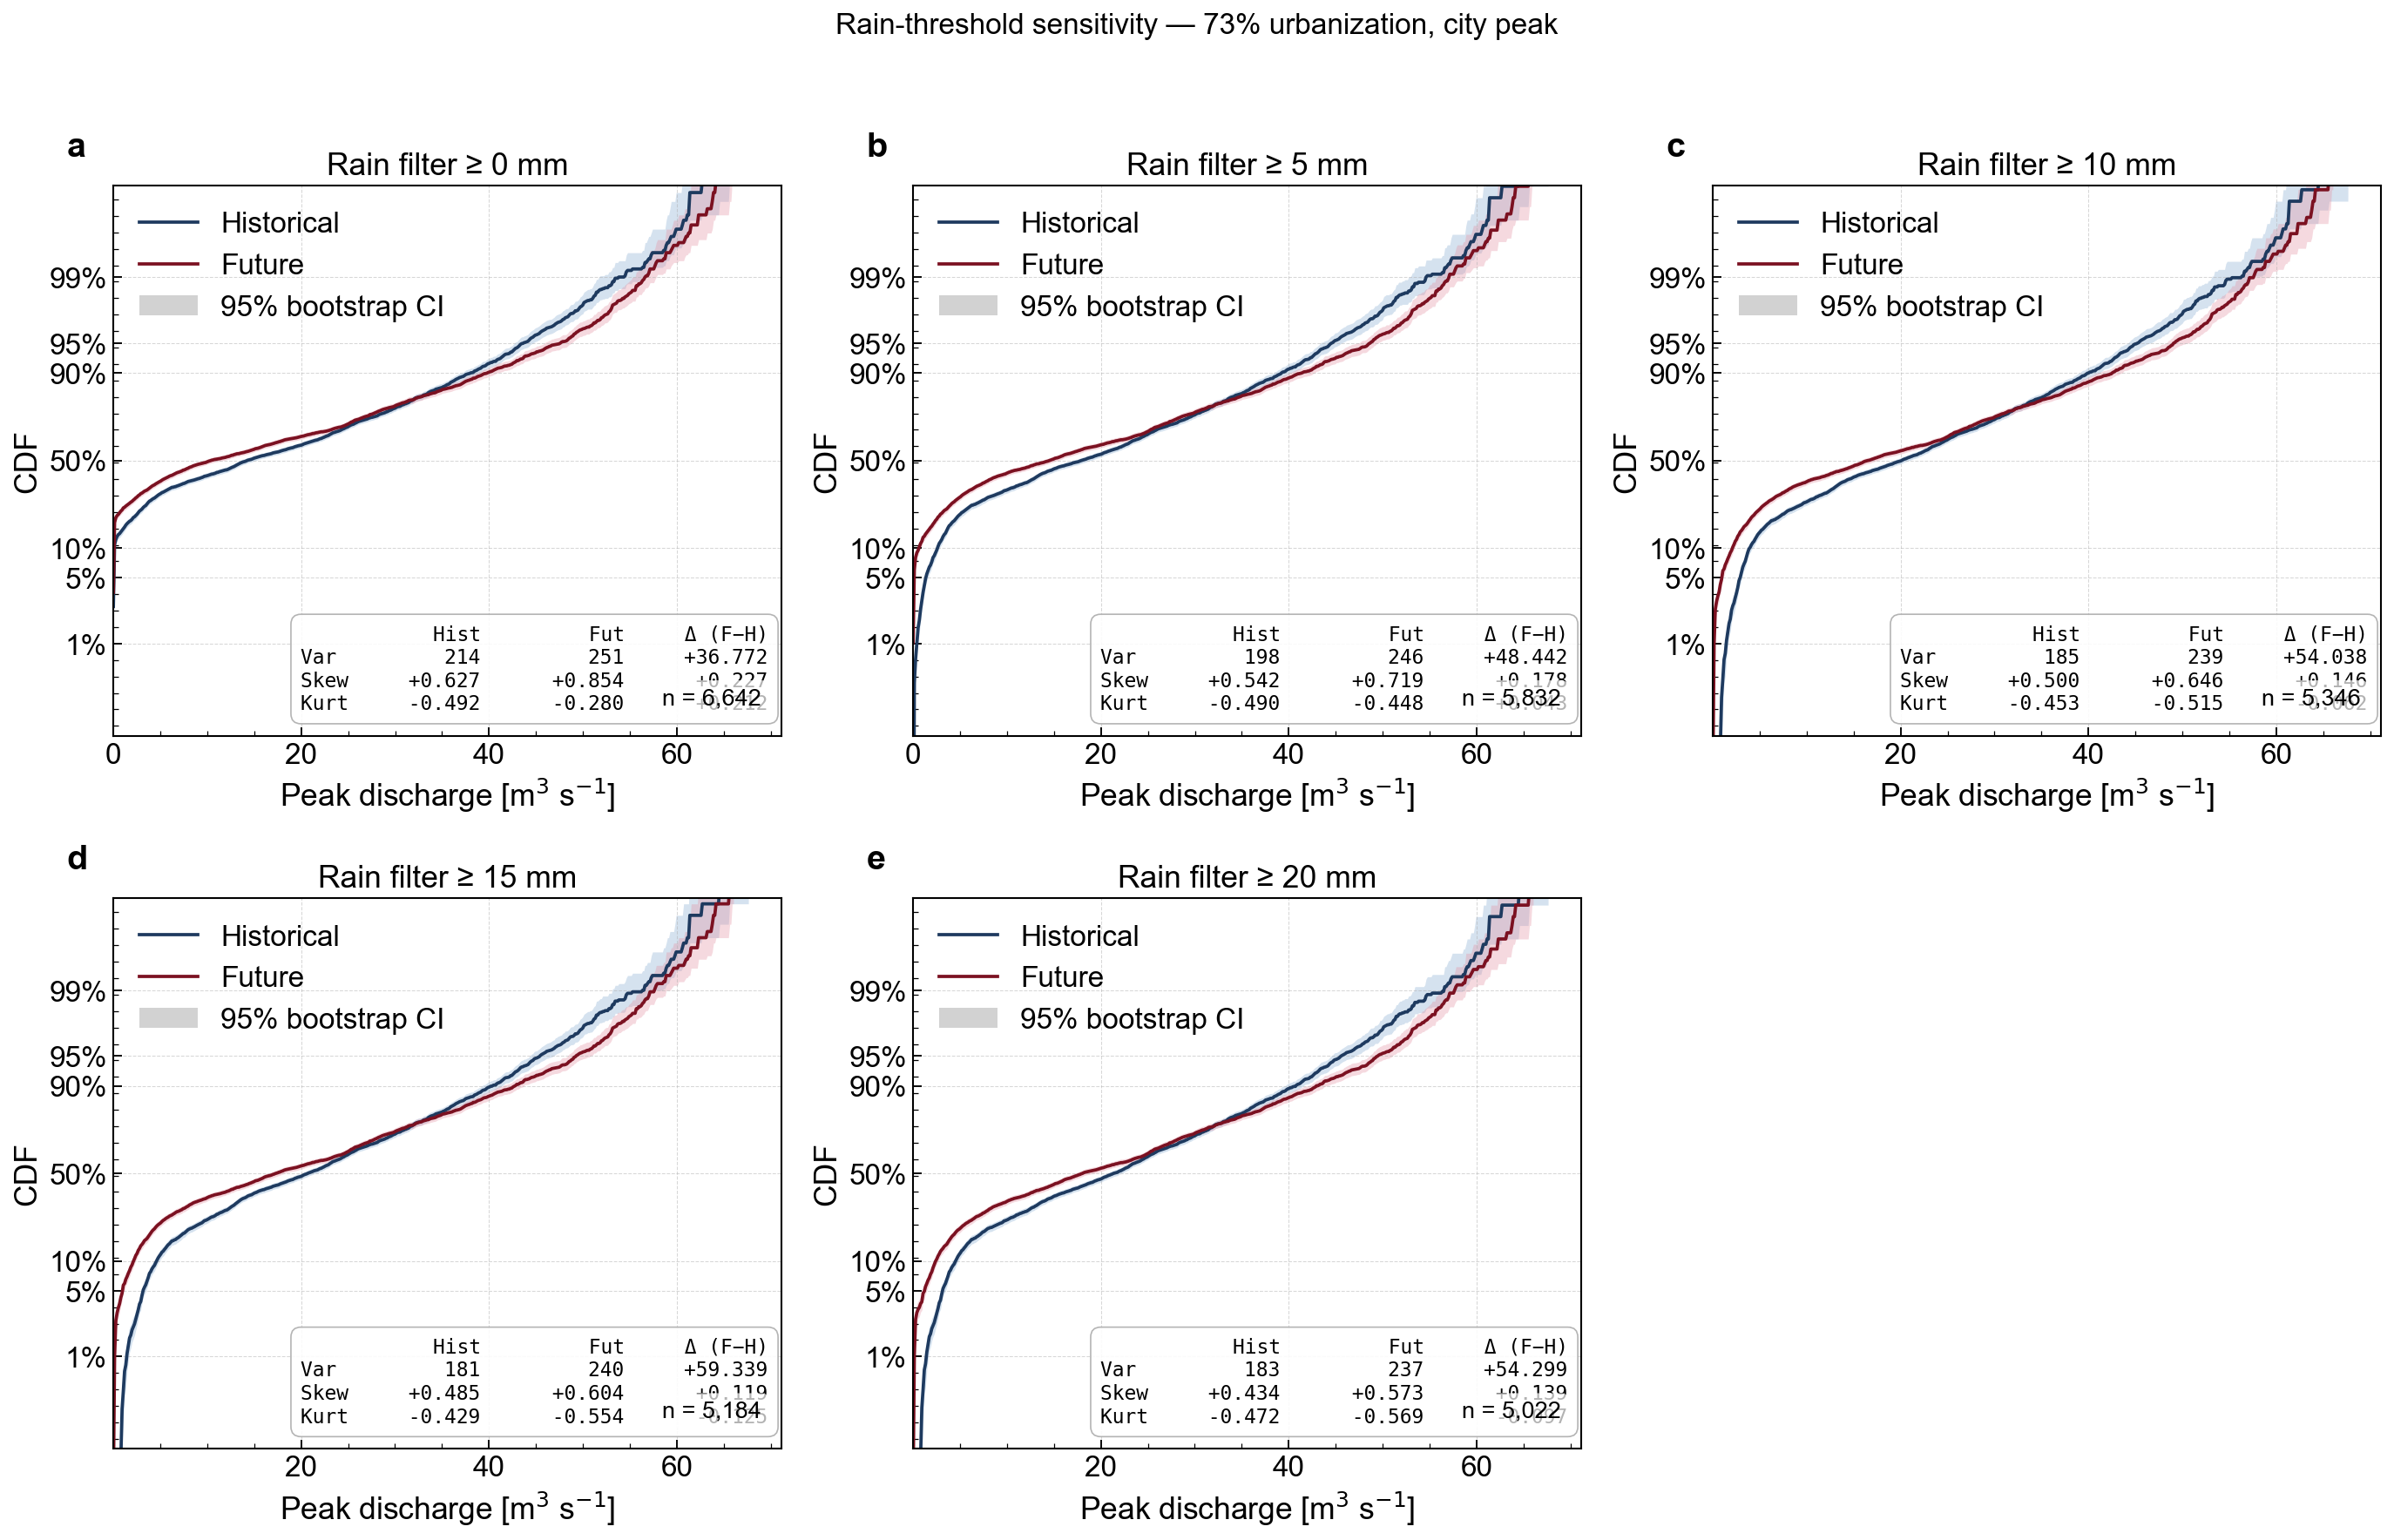

In [18]:
print("=== Figure 5 : Rain-Threshold Sensitivity — Peak discharge ===")

fig5 = make_threshold_figure(
    data_by_threshold, n_sims_by_threshold, RAIN_THRESHOLDS_MM, x_label_t,
    title     = f'Rain-threshold sensitivity — {THRESH_SCENARIO}, {THRESH_SCALE} {THRESH_METRIC}',
    save_path = os.path.join(SAVE_DIR, 'Fig5_rain_threshold_sensitivity.pdf'),
)
plt.show()


### Figure 6 — Same comparison, total runoff volume

Identical rain-threshold sensitivity grid, but using `('city', 'total')` from
`COLUMN_DEFS` instead of `('city', 'peak')` — i.e. total runoff volume rather
than peak discharge.


In [19]:
hist_col_tt, fut_col_tt, x_label_tt = COLUMN_DEFS[(THRESH_SCALE, 'total')]

print("Loading data across rain thresholds (total runoff) ...")
data_by_threshold_total = {}
n_sims_by_threshold_total = {}
for thr in RAIN_THRESHOLDS_MM:
    print(f"  Rain threshold = {thr} mm")
    loaded = load_data(
        SIM_DIR, [THRESH_SCENARIO], hist_col_tt, fut_col_tt,
        rain_filter_mm=thr,
    )[THRESH_SCENARIO]
    data_by_threshold_total[thr] = loaded

    n_events = len(np.unique(loaded['event_num']))
    n_rows   = len(loaded['historical'])
    n_sims   = 2 * n_rows  # historical + future simulations, across all (x, y) shifts
    n_sims_by_threshold_total[thr] = n_sims
    print(f"    -> {n_events} events | {n_rows} shift-rows | n = {n_sims:,} total simulations (historical + future)")


Loading data across rain thresholds (total runoff) ...
  Rain threshold = 0 mm
  Loading 73% urbanization ...
    Removed 0 events | 3321 rows kept
    -> 41 events | 3321 shift-rows | n = 6,642 total simulations (historical + future)
  Rain threshold = 5 mm
  Loading 73% urbanization ...
    Removed 5 events | 2916 rows kept
    -> 36 events | 2916 shift-rows | n = 5,832 total simulations (historical + future)
  Rain threshold = 10 mm
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
    -> 33 events | 2673 shift-rows | n = 5,346 total simulations (historical + future)
  Rain threshold = 15 mm
  Loading 73% urbanization ...
    Removed 9 events | 2592 rows kept
    -> 32 events | 2592 shift-rows | n = 5,184 total simulations (historical + future)
  Rain threshold = 20 mm
  Loading 73% urbanization ...
    Removed 10 events | 2511 rows kept
    -> 31 events | 2511 shift-rows | n = 5,022 total simulations (historical + future)


=== Figure 6 : Rain-Threshold Sensitivity — Total runoff ===
Saved -> D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig6_rain_threshold_sensitivity_total.pdf


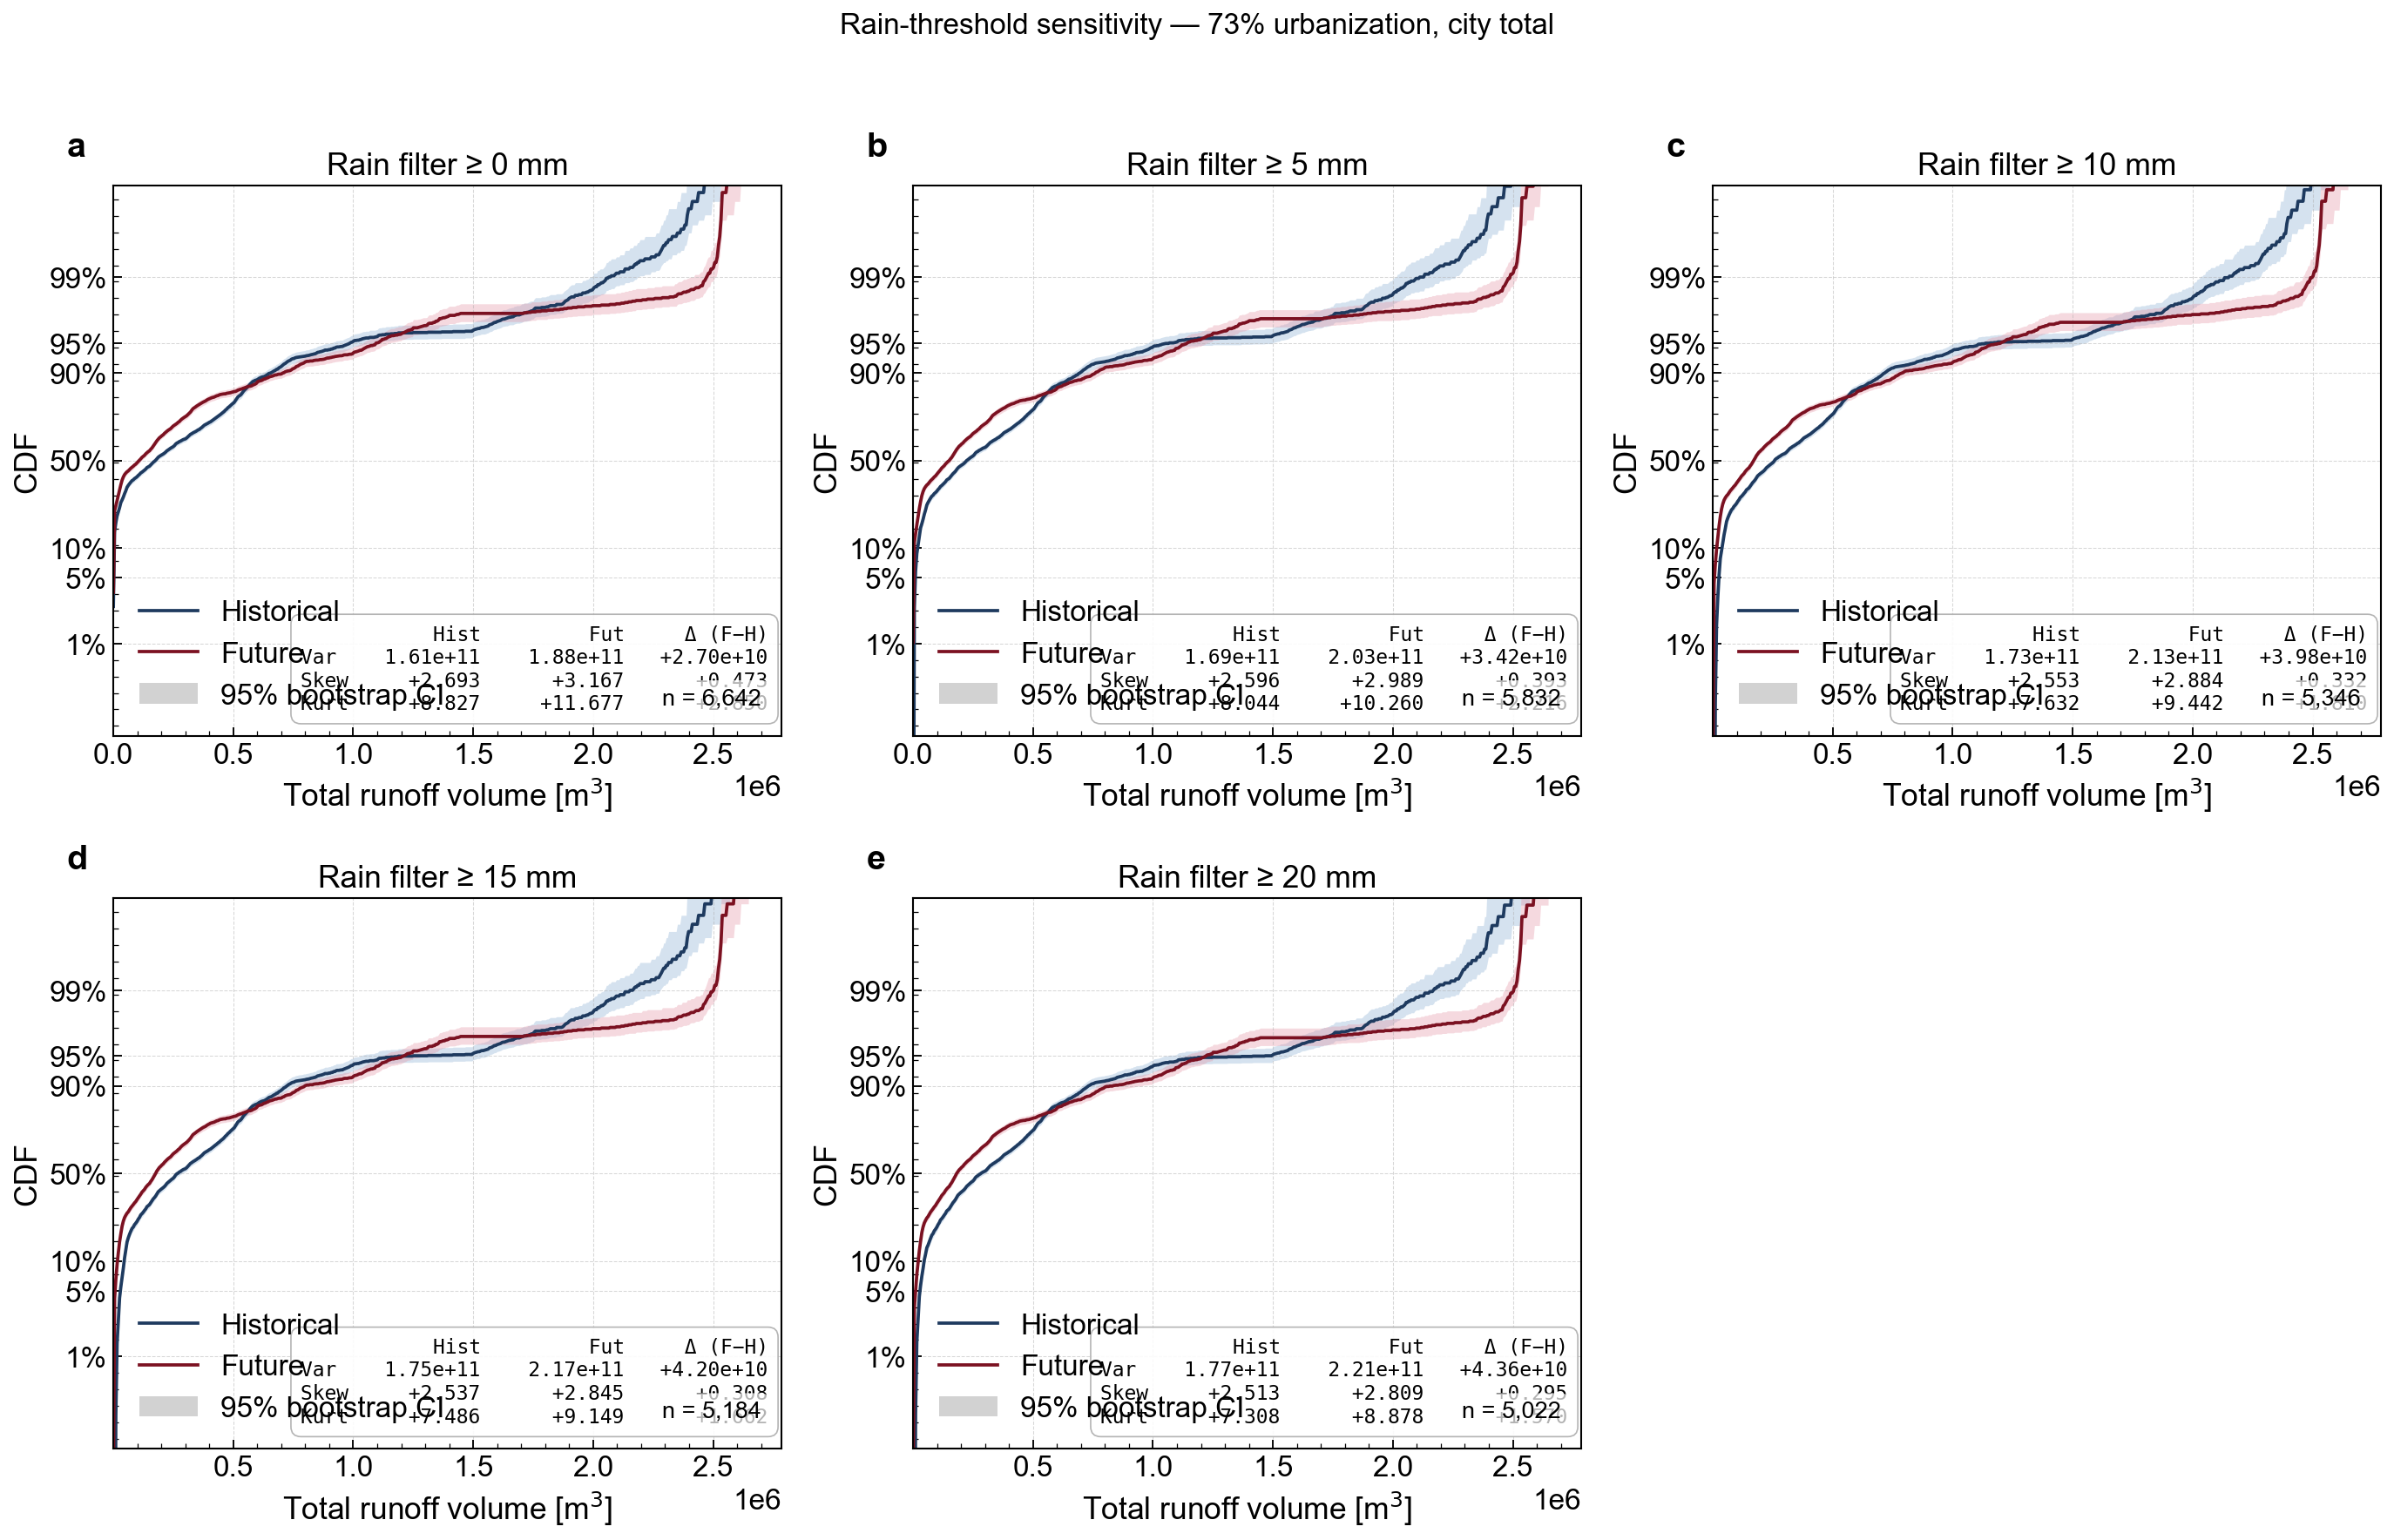

In [20]:
print("=== Figure 6 : Rain-Threshold Sensitivity — Total runoff ===")

fig6 = make_threshold_figure(
    data_by_threshold_total, n_sims_by_threshold_total, RAIN_THRESHOLDS_MM, x_label_tt,
    title     = f'Rain-threshold sensitivity — {THRESH_SCENARIO}, {THRESH_SCALE} total',
    save_path = os.path.join(SAVE_DIR, 'Fig6_rain_threshold_sensitivity_total.pdf'),
)
plt.show()


## 9 · Shift-Threshold Sensitivity of the CDF

How sensitive is the historical vs. future ECDF comparison to the maximum
allowed |Y-shift| (`SHIFT_THRESHOLD`, §2)? This section repeats the CDF
panel — Historical vs. Future, same logit-scale ECDF + bootstrap CI as
Figures 1–4 — once per shift threshold:

```
SHIFT_THRESHOLDS_M = [5_000, 10_000, 15_000, 20_000]   # [m]
```

Each subplot is one threshold; inside it, **Historical** and **Future** are
overlaid exactly like the other CDF panels (logit-scale ECDF + bootstrap CI
shading). The **rain filter is held constant** at `RAIN_FILTER_MM` (10 mm).

By default this uses `CDF_SCENARIO` and the city-scale metric — change
`SHIFT_SENS_SCALE` / `SHIFT_SENS_METRIC` / `SHIFT_SENS_SCENARIO` below
to compare a different metric or scenario.


In [21]:
# ── Shift thresholds to compare ───────────────────────────────────
SHIFT_THRESHOLDS_M = [5_000, 10_000, 15_000, 20_000]

# ── Metric / scale / scenario used for this comparison ───────────
SHIFT_SENS_SCALE    = 'city'
SHIFT_SENS_METRIC   = 'peak'
SHIFT_SENS_SCENARIO = CDF_SCENARIO

print(f"Shift thresholds : {SHIFT_THRESHOLDS_M} m")
print(f"Scenario         : {SHIFT_SENS_SCENARIO}")
print(f"Scale / metric   : {SHIFT_SENS_SCALE} / {SHIFT_SENS_METRIC}")


Shift thresholds : [5000, 10000, 15000, 20000] m
Scenario         : 73% urbanization
Scale / metric   : city / peak


In [22]:
hist_col_s, fut_col_s, x_label_s = COLUMN_DEFS[(SHIFT_SENS_SCALE, SHIFT_SENS_METRIC)]

print("Loading data across shift thresholds (peak discharge) ...")
data_by_shift = {}
n_sims_by_shift = {}
for thr in SHIFT_THRESHOLDS_M:
    print(f"  Shift threshold = {thr:,} m")
    loaded = load_data(
        SIM_DIR, [SHIFT_SENS_SCENARIO], hist_col_s, fut_col_s,
        rain_filter_mm=RAIN_FILTER_MM, shift_threshold=thr,
    )[SHIFT_SENS_SCENARIO]
    data_by_shift[thr] = loaded

    n_events = len(np.unique(loaded['event_num']))
    n_rows   = len(loaded['historical'])
    n_sims   = 2 * n_rows
    n_sims_by_shift[thr] = n_sims
    print(f"    -> {n_events} events | {n_rows} shift-rows | n = {n_sims:,} total simulations (historical + future)")


Loading data across shift thresholds (peak discharge) ...
  Shift threshold = 5,000 m
  Loading 73% urbanization ...
    Removed 8 events | 693 rows kept
    -> 33 events | 693 shift-rows | n = 1,386 total simulations (historical + future)
  Shift threshold = 10,000 m
  Loading 73% urbanization ...
    Removed 8 events | 1353 rows kept
    -> 33 events | 1353 shift-rows | n = 2,706 total simulations (historical + future)
  Shift threshold = 15,000 m
  Loading 73% urbanization ...
    Removed 8 events | 2013 rows kept
    -> 33 events | 2013 shift-rows | n = 4,026 total simulations (historical + future)
  Shift threshold = 20,000 m
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
    -> 33 events | 2673 shift-rows | n = 5,346 total simulations (historical + future)


=== Figure 7 : Shift-Threshold Sensitivity — Peak discharge ===
Saved -> D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig7_shift_threshold_sensitivity_peak.pdf


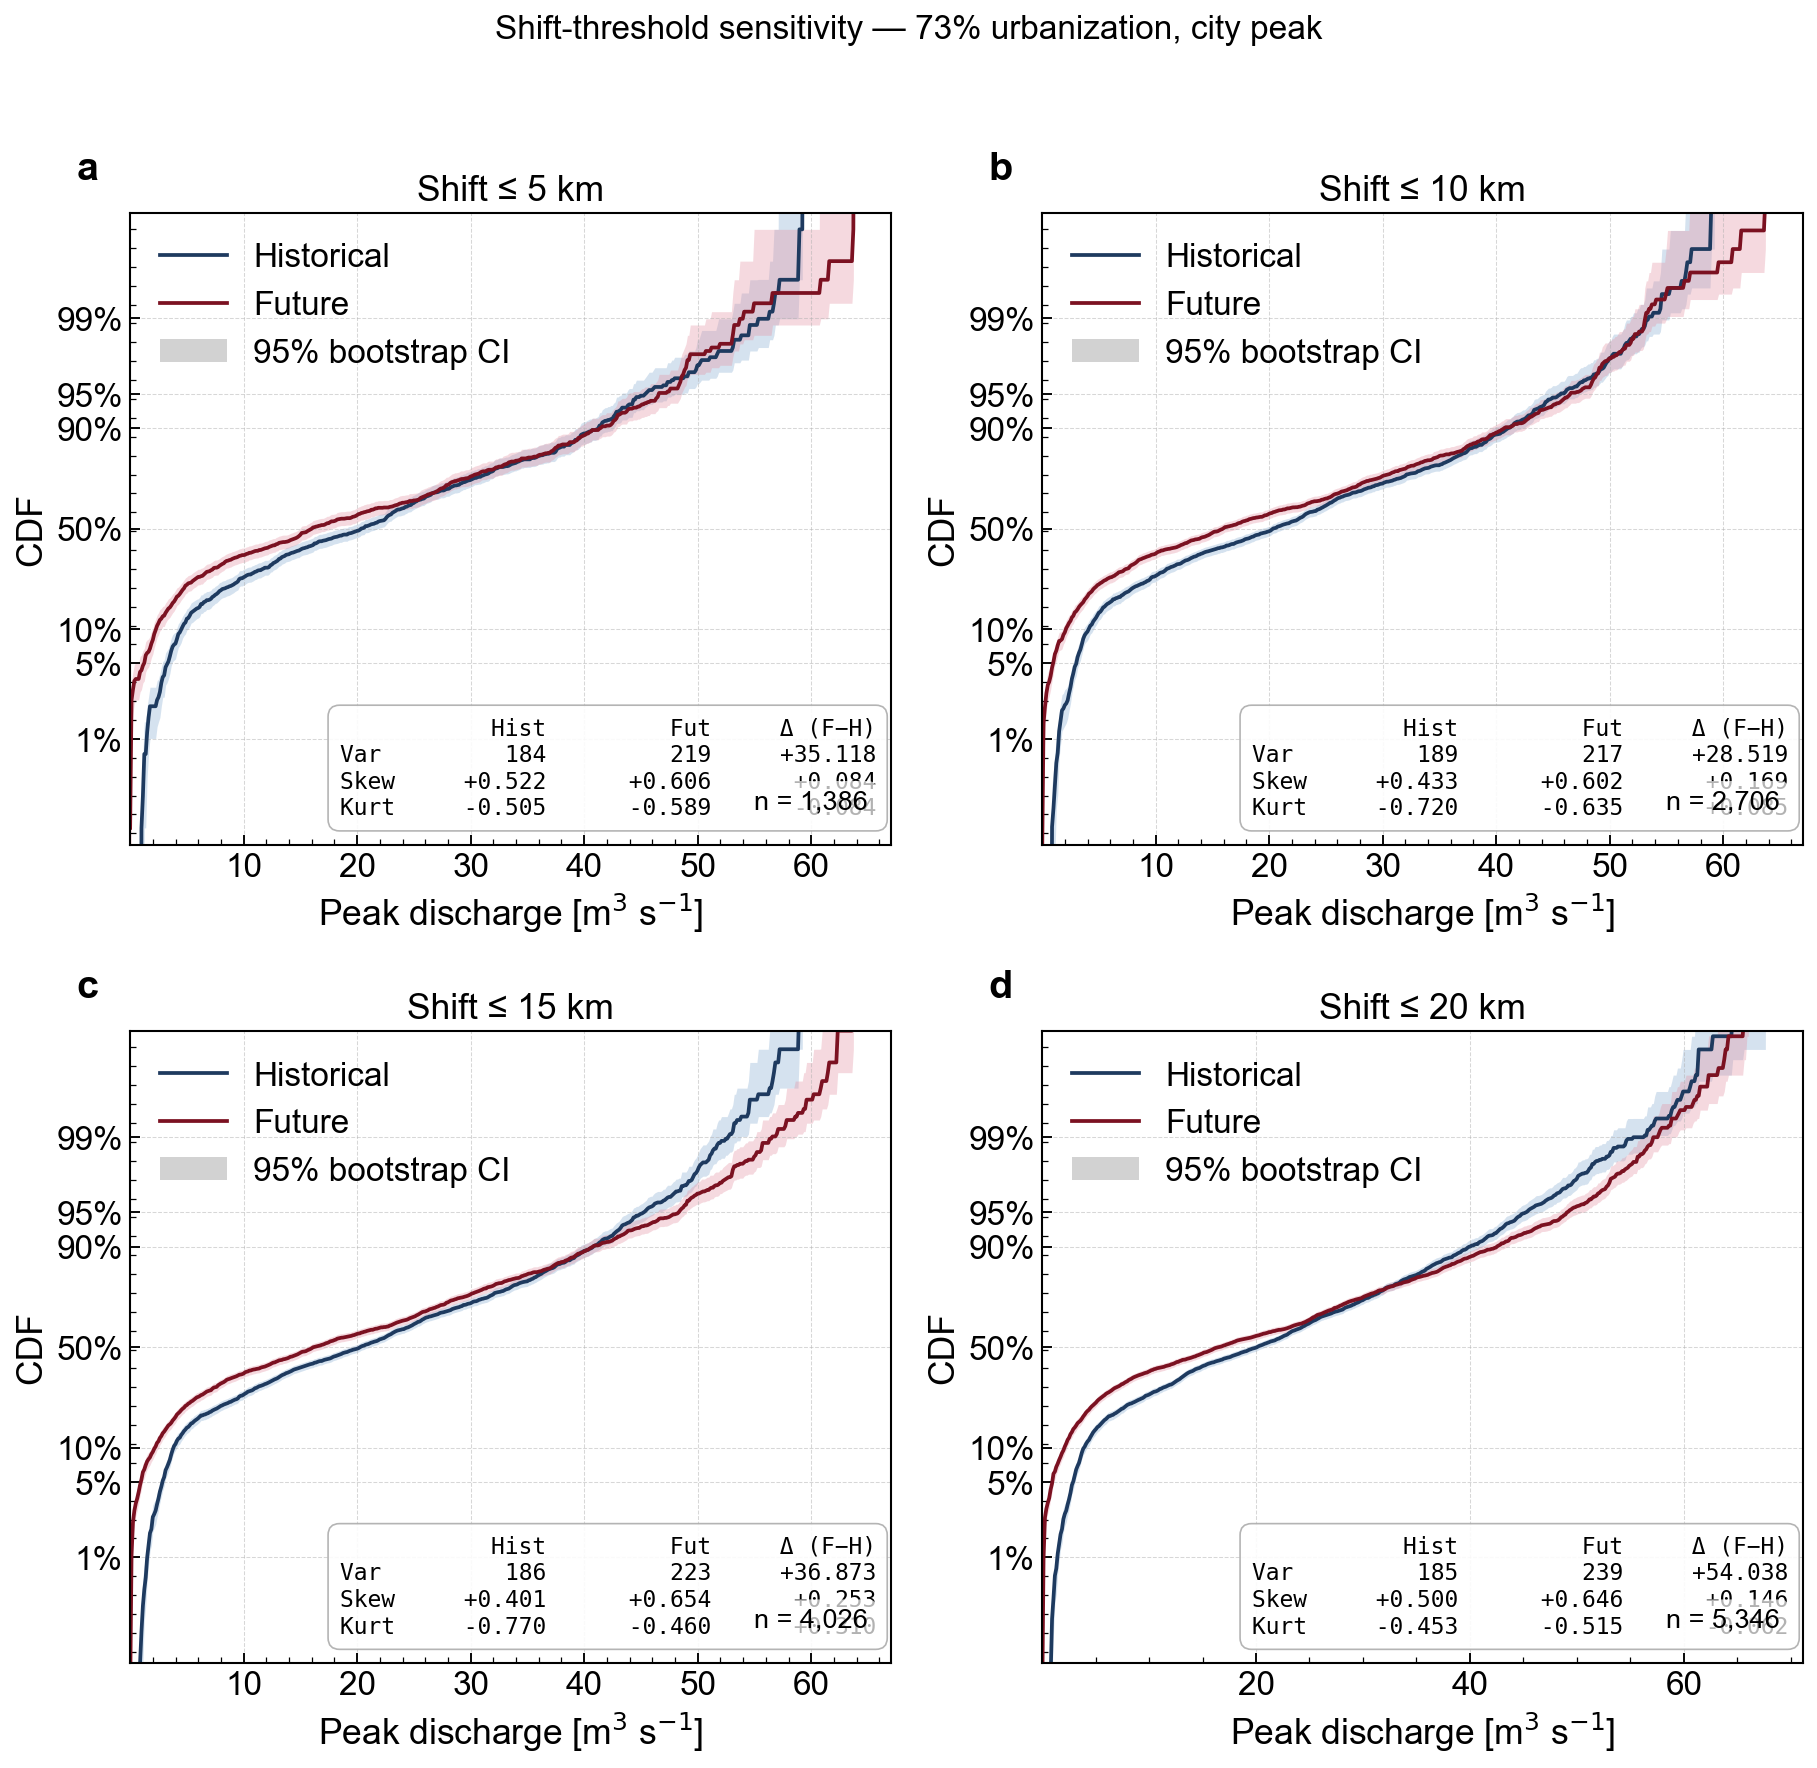

In [23]:
def make_shift_figure(data_by_shift, n_sims_by_shift, thresholds, x_label,
                      title, save_path,
                      alpha=ALPHA, n_boot=N_BOOT, ncols=2):
    # Grid of CDF panels varying shift threshold (rain filter held constant at RAIN_FILTER_MM).
    n_thr  = len(thresholds)
    nrows  = -(-n_thr // ncols)
    panel_labels = 'abcdefghij'

    fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 5.8 * nrows), dpi=150)
    axes = np.atleast_1d(axes).ravel()

    for i, thr in enumerate(thresholds):
        plot_cdf_panel(
            axes[i],
            hist_values = data_by_shift[thr]['historical'],
            fut_values  = data_by_shift[thr]['future'],
            x_label     = x_label,
            alpha       = alpha,
            n_boot      = n_boot,
            panel_label = panel_labels[i],
        )
        axes[i].set_title(f'Shift ≤ {thr // 1_000} km', fontsize=17)
        axes[i].text(
            0.97, 0.05, f'n = {n_sims_by_shift[thr]:,}',
            transform=axes[i].transAxes,
            fontsize=13, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='none'),
        )

    for j in range(n_thr, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=16, y=1.02)
    fig.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f'Saved -> {save_path}')

    return fig


print("=== Figure 7 : Shift-Threshold Sensitivity — Peak discharge ===")

fig7 = make_shift_figure(
    data_by_shift, n_sims_by_shift, SHIFT_THRESHOLDS_M, x_label_s,
    title     = f'Shift-threshold sensitivity — {SHIFT_SENS_SCENARIO}, {SHIFT_SENS_SCALE} {SHIFT_SENS_METRIC}',
    save_path = os.path.join(SAVE_DIR, 'Fig7_shift_threshold_sensitivity_peak.pdf'),
)
plt.show()


In [24]:
hist_col_st, fut_col_st, x_label_st = COLUMN_DEFS[(SHIFT_SENS_SCALE, 'total')]

print("Loading data across shift thresholds (total runoff) ...")
data_by_shift_total = {}
n_sims_by_shift_total = {}
for thr in SHIFT_THRESHOLDS_M:
    print(f"  Shift threshold = {thr:,} m")
    loaded = load_data(
        SIM_DIR, [SHIFT_SENS_SCENARIO], hist_col_st, fut_col_st,
        rain_filter_mm=RAIN_FILTER_MM, shift_threshold=thr,
    )[SHIFT_SENS_SCENARIO]
    data_by_shift_total[thr] = loaded

    n_events = len(np.unique(loaded['event_num']))
    n_rows   = len(loaded['historical'])
    n_sims   = 2 * n_rows
    n_sims_by_shift_total[thr] = n_sims
    print(f"    -> {n_events} events | {n_rows} shift-rows | n = {n_sims:,} total simulations (historical + future)")


Loading data across shift thresholds (total runoff) ...
  Shift threshold = 5,000 m
  Loading 73% urbanization ...
    Removed 8 events | 693 rows kept
    -> 33 events | 693 shift-rows | n = 1,386 total simulations (historical + future)
  Shift threshold = 10,000 m
  Loading 73% urbanization ...
    Removed 8 events | 1353 rows kept
    -> 33 events | 1353 shift-rows | n = 2,706 total simulations (historical + future)
  Shift threshold = 15,000 m
  Loading 73% urbanization ...
    Removed 8 events | 2013 rows kept
    -> 33 events | 2013 shift-rows | n = 4,026 total simulations (historical + future)
  Shift threshold = 20,000 m
  Loading 73% urbanization ...
    Removed 8 events | 2673 rows kept
    -> 33 events | 2673 shift-rows | n = 5,346 total simulations (historical + future)


=== Figure 8 : Shift-Threshold Sensitivity — Total runoff ===
Saved -> D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig8_shift_threshold_sensitivity_total.pdf


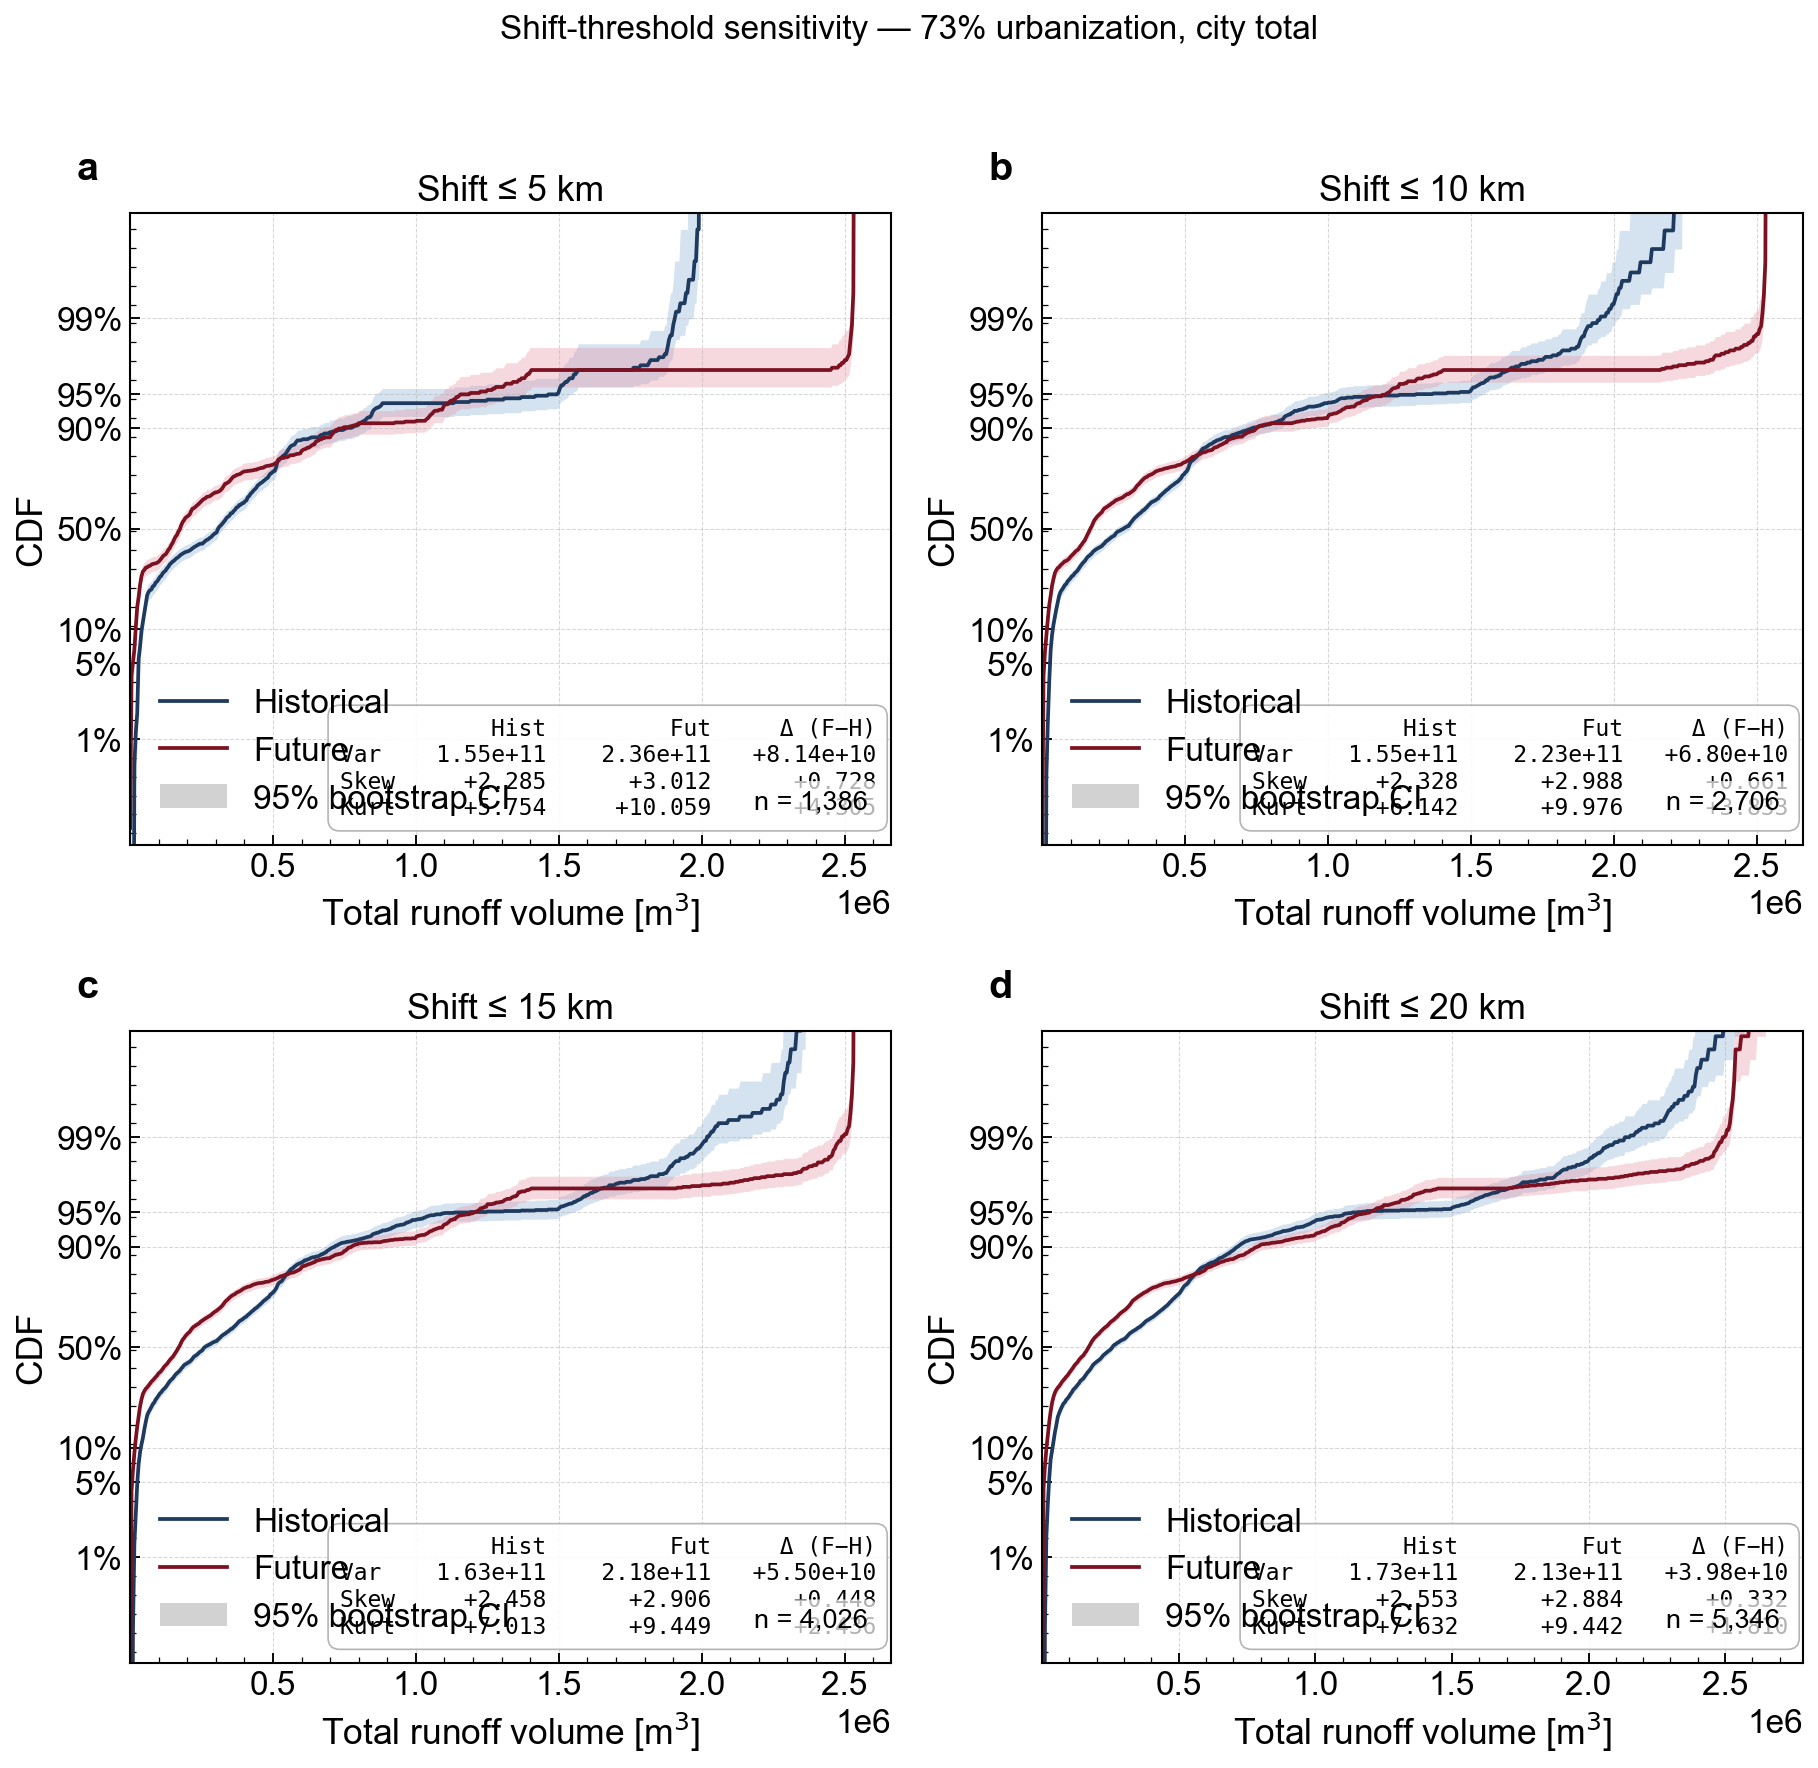

In [25]:
print("=== Figure 8 : Shift-Threshold Sensitivity — Total runoff ===")

fig8 = make_shift_figure(
    data_by_shift_total, n_sims_by_shift_total, SHIFT_THRESHOLDS_M, x_label_st,
    title     = f'Shift-threshold sensitivity — {SHIFT_SENS_SCENARIO}, {SHIFT_SENS_SCALE} total',
    save_path = os.path.join(SAVE_DIR, 'Fig8_shift_threshold_sensitivity_total.pdf'),
)
plt.show()
